# Project : 서울시 빅데이터 활용 경진대회
- 프로젝트 목적 : 서울시 공공 데이터를 바탕으로 N년간의 물품 가격의 시계열 패턴, 지역별 차이, 외부 요인에 의한 영향 등을 정량화하고 시민 체감형 물가 현황 대시보드를 제작
- 데이터 정보
    - 규모 : 319,296 rows * 19 columns
    - 기간 : 2023-01-20 ~ 2026-04-14
    - 출처 : [서울 데이터 허브](https://data.seoul.go.kr/bsp/wgs/dataView/data300View/10003.do)
- 최종 수정 : 2026-05-01

## 라이브러리 import

In [40]:
# 데이터 처리
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy import stats
from datetime import datetime
import re
import math

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
# import missingno as msno  # 결측치 분포 시각화
## 한글 깨짐 방지
# 윈도우
# plt.rcParams['font.family'] = 'Malgun Gothic'
# plt.rcParams['axes.unicode_minus'] = False
# 맥
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# 판다스 출력 옵션 설정 (데이터가 많을 때 생략되는 것을 방지)
pd.set_option('display.max_columns', None)  # 모든 컬럼 출력
pd.set_option('display.max_rows', None)  # 모든 행 출력
pd.set_option('display.float_format', '{:.4f}'.format) # 소수점 4자리까지 고정 (가독성 향상)

# 그 외
# 경고 무시
import warnings
warnings.filterwarnings("ignore")

# 시스템
import os
import gc

## 데이터 로드 & 탐색

In [41]:
PATH = '/Users/hyun/Documents/project/seoul-market-price-analysis/data/raw/'

df25 = pd.read_csv(f'{PATH}생필품 농수축산물 가격 정보(2025년이후).csv', header=1, low_memory=False) # 모든 데이터를 문자로 읽어옴, 메모리 경고를 끄고 한 번에 읽어서 타입을 추론
df24 = pd.read_csv(f'{PATH}생필품 농수축산물 가격 정보(2024년).csv', low_memory=False, encoding='cp949')
df23 = pd.read_csv(f'{PATH}생필품 농수축산물 가격 정보(2023년).csv', low_memory=False, encoding='cp949')

df25.shape, df24.shape, df23.shape

((144684, 19), (98053, 14), (76559, 14))

## preprocessing & feature engineering

### 데이터셋 통합 전

#### 칼럼명 통일

In [42]:
col_mapping = {
    '일련번호':                         'sn',
    '시장/마트 번호':                   'mkplc_mart_no',
    '시장/마트 이름':                   'mkplc_mart_nm',
    '품목 번호':                        'prdlst_no',
    '품목 이름':                        'prdlst_nm',
    '실판매규격':                       'real_sle_stndrd',
    '가격(원)':                         'pc',
    '년도-월':                          'ym',
    '비고':                             'rmrk',
    '시장유형 구분(시장/마트) 코드':    'mkplc_type_cd',
    '시장유형 구분(시장/마트) 이름':    'mkplc_type_nm',
    '자치구 코드':                      'atdrc_cd',
    '자치구 이름':                      'atdrc',
    '점검일자':                         'chck_ymd',
}

df23.rename(columns=col_mapping, inplace=True)
df24.rename(columns=col_mapping, inplace=True)

print("✅ 칼럼명 통일 완료")

✅ 칼럼명 통일 완료


#### 칼럼별 데이터타입 통일

In [43]:
# ym 칼럼 포맷 통일
# df23 : '2023-02' 형식
df23['ym'] = pd.to_datetime(df23['ym'], format='%Y-%m', errors='coerce').dt.strftime('%Y-%m')
# df24 : 'Jan-24' 형식
df24['ym'] = pd.to_datetime(df24['ym'], format='%b-%y', errors='coerce').dt.strftime('%Y-%m')
# df25 : '2025-01' 형식
df25['ym'] = pd.to_datetime(df25['ym'], format='%Y-%m', errors='coerce').dt.strftime('%Y-%m')

# 2023-01 제거 (98건, 2월 누락으로 연속성 없음)
df23 = df23[df23['ym'] != '2023-01'].copy()

# mkplc_type_cd 타입 통일
for df in [df23, df24, df25]:
    df['mkplc_type_cd'] = df['mkplc_type_cd'].astype('Int64')

print("✅ ym 포맷 통일 완료")
print(f"  df23: {df23['ym'].min()} ~ {df23['ym'].max()}")
print(f"  df24: {df24['ym'].min()} ~ {df24['ym'].max()}")
print(f"  df25: {df25['ym'].min()} ~ {df25['ym'].max()}")

✅ ym 포맷 통일 완료
  df23: 2023-03 ~ 2023-12
  df24: 2024-01 ~ 2024-12
  df25: 2025-01 ~ 2026-04


#### 품목명 파싱으로 대표품목명 변수 생성

In [44]:
def parse_item_details(text):
    """prdlst_nm → (핵심품목명, 품종, 규격) 분해"""
    if pd.isna(text):
        return '기타', '기본', '규격없음'

    text = str(text)

    # 품종/산지: 괄호 안 텍스트
    v_match = re.search(r'\((.*?)\)', text)
    variety = v_match.group(1).strip() if v_match else '기본'

    # 규격: 숫자 + 단위
    s_match = re.search(r'(\d+(?:\.\d+)?\s*[a-zA-Z가-힣]+)', text)
    spec = s_match.group(1).strip() if s_match else '규격없음'

    # 핵심 품목명: 괄호·숫자·단위·특수문자 제거
    core = re.sub(r'\(.*?\)', '', text)
    core = re.sub(r'\d+(?:\.\d+)?\s*[a-zA-Z가-힣]*', '', core)
    core = re.sub(r'[.,/]', '', core).strip()
    core = ' '.join(core.split())

    return core, variety, spec

for name, df in [('df23', df23), ('df24', df24), ('df25', df25)]:
    parsed = df['prdlst_nm'].apply(parse_item_details)
    df['new_std_nm'] = [x[0] for x in parsed]
    df['variety']    = [x[1] for x in parsed]
    df['spec']       = [x[2] for x in parsed]
    print(f"  {name} 파싱 완료 → 고유 품목 수: {df['new_std_nm'].nunique()}개")

print("✅ 품목명 파싱 완료")

  df23 파싱 완료 → 고유 품목 수: 103개
  df24 파싱 완료 → 고유 품목 수: 99개
  df25 파싱 완료 → 고유 품목 수: 106개
✅ 품목명 파싱 완료


In [45]:
ori_all_unique_set = set(df23['prdlst_nm']) | set(df24['prdlst_nm']) | set(df25['prdlst_nm'])
print(f"  전체 3개년도 고유 품목 수: {len(ori_all_unique_set)}개")

  전체 3개년도 고유 품목 수: 205개


In [46]:
all_unique_set = set(df23['new_std_nm']) | set(df24['new_std_nm']) | set(df25['new_std_nm'])
print(f"  전체 3개년도 고유 대표품목 수: {len(all_unique_set)}개")

  전체 3개년도 고유 대표품목 수: 128개


#### 품목번호 맵핑오류 처리

In [47]:
# 임계값 설정
THRESHOLD = 0.05  # 5% 미만이면 오입력으로 판단

def detect_mapping_errors(df, year_label, threshold=THRESHOLD):
    df = df.copy()

    # 결측치 처리 ('기타' → prdlst_no 기준 최빈 new_std_nm으로 대체)
    mode_map = (
        df[df['new_std_nm'] != '기타']
        .groupby('prdlst_no')['new_std_nm']
        .agg(lambda x: x.value_counts().index[0])
        .to_dict()
    )

    null_before = (df['new_std_nm'] == '기타').sum()
    df['new_std_nm'] = df.apply(
        lambda row: mode_map.get(row['prdlst_no'], '기타')
        if row['new_std_nm'] == '기타' else row['new_std_nm'],
        axis=1
    )
    null_after = (df['new_std_nm'] == '기타').sum()
    print(f"\n[{year_label}]")
    print(f"  결측치(기타) 처리: {null_before:,}건 → {null_after:,}건")

    # 오입력 탐지
    total_counts  = df.groupby('prdlst_no')['new_std_nm'].transform('count')
    mode_per_code = df.groupby('prdlst_no')['new_std_nm'].transform(
        lambda x: x.value_counts().index[0]
    )
    item_counts = df.groupby(['prdlst_no', 'new_std_nm'])['new_std_nm'].transform('count')

    df['_ratio']     = item_counts / total_counts
    df['_mode_item'] = mode_per_code
    df['_is_wrong']  = (
        (df['new_std_nm'] != df['_mode_item']) &
        (df['_ratio'] < threshold)
    )

    # 소멸 품목 보호
    wrong_items   = set(df[df['_is_wrong']]['new_std_nm'])
    correct_items = set(df[~df['_is_wrong']]['new_std_nm'])
    vanishing     = wrong_items - correct_items

    if vanishing:
        print(f"  소멸 보호 품목: {sorted(vanishing)}")
        df['_is_wrong'] = df['_is_wrong'] & ~df['new_std_nm'].isin(vanishing)

    # drop 목록 출력 (확인용)
    wrong_summary = (
        df[df['_is_wrong']]
        .groupby(['prdlst_no', '_mode_item', 'new_std_nm'])
        .size()
        .reset_index(name='건수')
        .rename(columns={'_mode_item': '정답품목', 'new_std_nm': '오입력품목'})
        .sort_values(['prdlst_no', '건수'], ascending=[True, False])
    )
    print(f"  drop 예정: {df['_is_wrong'].sum():,}건 ({len(wrong_summary)}종)")
    if not wrong_summary.empty:
        print(wrong_summary.to_string(index=False))

    return df  # _is_wrong 칼럼 포함한 상태로 반환 (drop 미실행)

df23 = detect_mapping_errors(df23, 'df23')
df24 = detect_mapping_errors(df24, 'df24')
df25 = detect_mapping_errors(df25, 'df25')

print("\n👆 위 목록 확인 후 drop 진행.")


[df23]
  결측치(기타) 처리: 194건 → 0건
  소멸 보호 품목: ['마늘', '소금', '파', '호박']
  drop 예정: 1,261건 (442종)
 prdlst_no 정답품목 오입력품목  건수
         4  복숭아     배   4
         4  복숭아    버섯   3
         4  복숭아    배추   1
         7    귤    국수   6
         7    귤    단감   3
         8  오렌지    양파  10
         8  오렌지     귤   3
         8  오렌지    단감   1
         8  오렌지    사과   1
         8  오렌지    설탕   1
         8  오렌지    소주   1
         8  오렌지    식초   1
         8  오렌지     쌀   1
         9   참외   오렌지   4
         9   참외    조기   4
         9   참외    설탕   1
         9   참외   소고기   1
         9   참외    소주   1
         9   참외   시금치   1
         9   참외    우유   1
         9   참외    조개   1
         9   참외   즉석밥   1
        10   수박    소주  10
        10   수박    참외   3
        10   수박    비누   1
        10   수박    상추   1
        10   수박    생수   1
        10   수박   오렌지   1
        11   딸기    두부   5
        11   딸기    된장   4
        11   딸기    수박   4
        11   딸기    당근   2
        11   딸기  돼지고기   1
        11   딸기    참외  

In [48]:
# 손실예정품목별 갯수 확인
# 1. 데이터셋 리스트와 연도 이름 설정
datasets = [df23, df24, df25]
years = ['2023년', '2024년', '2025년']

# 2. 손실된 품목 리스트 (아래 코드 확인 후 리스트 작성)
lost_items = {'고춧가루 1kg', '새우 1kg', '배 1개', '버섯 100g', '파프리카 100g'}

print("=== 연도별 손실 예정 품목 리스트업 ===\n")

for year_label, df in zip(years, datasets):
    print(f"[{year_label} 데이터 확인]")
    
    # 해당 데이터셋에 lost_items 중 존재하는 것들만 필터링
    counts = df[df['prdlst_nm'].isin(lost_items)]['prdlst_nm'].value_counts()
    
    if counts.empty:
        print(" -> 해당 연도에는 손실 예정 품목이 존재하지 않습니다.")
    else:
        for item, cnt in counts.items():
            print(f" - {item}: {cnt}개")
            
    print("-" * 35)

=== 연도별 손실 예정 품목 리스트업 ===

[2023년 데이터 확인]
 - 파프리카 100g: 21개
 - 새우 1kg: 20개
 - 배 1개: 19개
 - 버섯 100g: 16개
 - 고춧가루 1kg: 12개
-----------------------------------
[2024년 데이터 확인]
 -> 해당 연도에는 손실 예정 품목이 존재하지 않습니다.
-----------------------------------
[2025년 데이터 확인]
 -> 해당 연도에는 손실 예정 품목이 존재하지 않습니다.
-----------------------------------


In [49]:
# 맵핑 오류 목록 drop
def apply_drop(df, year_label):
    df = df[~df['_is_wrong']].copy()
    df.drop(columns=['_ratio', '_mode_item', '_is_wrong'], inplace=True)
    print(f"[{year_label}] 처리 후: {len(df):,}행")
    return df

df23 = apply_drop(df23, 'df23')
df24 = apply_drop(df24, 'df24')
df25 = apply_drop(df25, 'df25')

print("\n✅ 맵핑 오류 처리 완료")

[df23] 처리 후: 75,200행
[df24] 처리 후: 97,571행
[df25] 처리 후: 144,684행

✅ 맵핑 오류 처리 완료


In [50]:
# drop 후 확인
ori_after_drop_set = set(df23['prdlst_nm']) | set(df24['prdlst_nm']) | set(df25['prdlst_nm'])

# 손실된 품목 확인
print(f"  drop 후 전체 3개년도 고유 품목 수: {len(ori_after_drop_set)}개")

ori_lost = ori_all_unique_set - ori_after_drop_set
print(f"  drop으로 손실된 품목 수: {len(ori_lost)}개")
print(f"  손실된 품목: {ori_lost}")

  drop 후 전체 3개년도 고유 품목 수: 200개
  drop으로 손실된 품목 수: 5개
  손실된 품목: {'버섯 100g', '배 1개', '새우 1kg', '고춧가루 1kg', '파프리카 100g'}


In [51]:
# drop 후 확인
after_drop_set = set(df23['new_std_nm']) | set(df24['new_std_nm']) | set(df25['new_std_nm'])

# 손실된 품목 확인
print(f"  drop 후 전체 3개년도 고유 대표품목 수: {len(after_drop_set)}개")

lost = all_unique_set - after_drop_set
print(f"  drop으로 손실된 대표품목 수: {len(lost)}개")
print(f"  손실된 대표품목: {lost}")

  drop 후 전체 3개년도 고유 대표품목 수: 127개
  drop으로 손실된 대표품목 수: 1개
  손실된 대표품목: {'기타'}


#### 데이터 통합

In [52]:
df_total = pd.concat([df23, df24, df25], axis=0, ignore_index=True)

print(f"✅ 통합 완료: {df_total.shape[0]:,}행 × {df_total.shape[1]}열")
del df23, df24, df25
gc.collect()
print("   원본 데이터프레임 메모리 해제")

✅ 통합 완료: 317,455행 × 22열
   원본 데이터프레임 메모리 해제


In [53]:
print(df_total['prdlst_nm'].nunique(dropna=False))
df_total['prdlst_nm'].value_counts().sort_index()

200


prdlst_nm
 쌀(오대쌀) 10kg 1포     1128
 쌀(오대쌀) 20kg 1포      658
 쌀(오대쌀) 4kg 1포       934
 쌀(이천쌀) 10kg 1포     1119
 쌀(이천쌀) 20kg 1포     1597
 쌀(이천쌀) 4kg 1포       876
가지 1개                472
간장 1통               3756
갈치 1마리               858
갈치(냉동) 1마리(대)        217
갈치(냉동) 1마리(소)        102
갈치(냉동) 1마리(중)        305
갈치(생물) 1마리(대)       1916
갈치(생물) 1마리(소)        199
갈치(생물) 1마리(중)        723
감 10개                  1
감자 100g             3003
감자 1kg               957
갓 1kg                468
계란 10개              3512
고구마 1kg              950
고구마(밤고구마) 1kg       2969
고구마(호박고구마) 1kg      1528
고등어 1마리              864
고등어(신선냉장) 1마리(대)    1682
고등어(신선냉장) 1마리(중)     878
고등어(염장) 1손(대)       1089
고등어(염장) 1손(중)        756
고무장갑                  36
고추장 1kg             3646
고춧가루(국산) 1kg        3666
골드키위(1팩)             918
국수 900g             3752
굴 1kg                474
굵은소금(천일염) 1kg       3407
귤 10개                911
귤(제주산) 10개          2337
기저귀                    9
김치 3.3kg 1개          270
깐마늘 1kg        

In [54]:
print(df_total['new_std_nm'].nunique(dropna=False))
df_total['new_std_nm'].value_counts().sort_index()

127


new_std_nm
가지         472
간장        3761
갈치        4320
감            1
감자        3965
갓          468
계란        3512
고구마       5449
고등어       5270
고무장갑        36
고추장       3655
고춧가루      3667
골드키위       918
국수        3753
굴          474
굵은소금      3410
귤         3248
기저귀          9
김치         270
깐마늘       3847
깻잎        3848
꽃게         464
꽈리고추      1727
낙지         467
단감        3067
닭고기       3656
당근        3895
대추          81
대파        3955
도라지        468
돼지고기      3890
된장        3662
두부        3281
딸기        3153
라면        3830
마늘           5
마른멸치      3751
마요네즈      3803
만두        2814
맛김        2786
맥주        3559
멸치액젓       470
명태        3279
무         3961
물티슈         24
미나리        474
밀가루       3557
바나나       3674
바디워시      2811
밤           71
방울토마토     1702
배         3857
배추        3862
버섯        3843
복숭아       2407
부추         476
부침가루      3718
분유         816
붉은고추      1491
브로콜리      1834
비누        3386
빵         3046
사과        3868
사이다       3546
상추        5475
새우        2470

### 시장마트명 결측치 처리

In [55]:
# 1. mkplc_mart_no와 mkplc_mart_nm의 대응 관계를 사전(dict)으로 생성
# 결측치가 없는 행들만 추출하여 번호를 인덱스로, 이름을 값으로 설정
mapping_dict = df_total.dropna(subset=['mkplc_mart_nm']).set_index('mkplc_mart_no')['mkplc_mart_nm'].to_dict()

# 2. mkplc_mart_nm이 결측치인 경우, mkplc_mart_no를 기준으로 매핑 사전에서 값을 찾아 채움
df_total['mkplc_mart_nm'] = df_total['mkplc_mart_nm'].fillna(df_total['mkplc_mart_no'].map(mapping_dict))

print(f"✅ 시장마트번호 결측치: {df_total['mkplc_mart_nm'].isnull().sum():,}건")

✅ 시장마트번호 결측치: 0건


### 전통시장 데이터만 필터링

- 대형마트 18,807 건으로 불균형이 너무 심해서 전통시장 vs 대형마트 비교보다 전통시장 물가 현황 방향으로 진행

In [56]:
df_total = df_total[df_total['mkplc_type_nm'] == '전통시장'].copy()
df_total['chck_ymd'] = pd.to_datetime(df_total['chck_ymd'])
df_total = df_total.sort_values('chck_ymd').reset_index(drop=True)

print(f"✅ 전통시장 필터링 후: {len(df_total):,}행")

✅ 전통시장 필터링 후: 298,648행


In [57]:
# # 1. 전체 품목 집합 (전처리 전)
# all_items = set(df_total['prdlst_nm'].unique())

# # 2. 전처리 후 남은 품목 집합
# remaining_items = set(df_totala['prdlst_nm'].unique())

# # 3. 차집합을 통해 완전히 사라진 품목 식별
# lost_items = all_items - remaining_items

# print(f"📊 대형마트 필터링으로 인해 완전히 소실된 품목 수: {len(lost_items)}개")
# if lost_items:
#     print(f"🔎 소실된 품목 리스트: {lost_items}")
# else:
#     print("✅ 모든 품목이 최소 1개 이상의 정상 가격 데이터를 가지고 있어 소실된 품목명이 없습니다.")

In [58]:
# # 1. 전체 품목 집합 (전처리 전)
# all_items = set(df_total['new_std_nm'].unique())

# # 2. 전처리 후 남은 품목 집합
# remaining_items = set(df_total['new_std_nm'].unique())

# # 3. 차집합을 통해 완전히 사라진 품목 식별
# lost_items = all_items - remaining_items

# print(f"📊 대형마트 필터링으로 인해 완전히 소실된 품목 수: {len(lost_items)}개")
# if lost_items:
#     print(f"🔎 소실된 품목 리스트: {lost_items}")
# else:
#     print("✅ 모든 품목이 최소 1개 이상의 정상 가격 데이터를 가지고 있어 소실된 품목명이 없습니다.")

### 시계열 파생변수 생성

In [59]:
# 시계열 파생변수 (반기 / 분기 / 계절)
def get_season(month):
    if month in [3, 4, 5]:    return '봄'
    elif month in [6, 7, 8]:  return '여름'
    elif month in [9, 10, 11]: return '가을'
    else:                      return '겨울'

df_total['반기'] = df_total['chck_ymd'].dt.month.apply(lambda m: '상반기' if m <= 6 else '하반기')
df_total['분기'] = df_total['chck_ymd'].dt.quarter
df_total['계절'] = df_total['chck_ymd'].dt.month.apply(get_season)

print("✅ 시계열 파생변수 생성 완료")

✅ 시계열 파생변수 생성 완료


### 가격 관련 전처리

#### 보정 가격 계산(특정 품목)

In [60]:
# 특정 품목 대표 규격 단위로 가격 보정
def calculate_standard_price(row):
    """규격별 가격을 단일 기준 단위 가격으로 보정"""
    item    = row['new_std_nm']
    variety = row['variety']
    spec    = row['spec']
    price   = row['pc']

    detailed_nm = f"{item}_{variety}" if variety != '기본' else item

    num_match = re.search(r'(\d+(?:\.\d+)?)', spec)
    amount = float(num_match.group(1)) if num_match else 1.0

    adj_price = price
    is_valid  = True

    if item == '쌀':
        adj_price = (price / amount) * 10 if 'kg' in spec else price
        is_valid  = 'kg' in spec

    elif item in ['소고기', '돼지고기', '닭고기', '감자']:
        if 'kg' in spec:
            adj_price = (price / (amount * 1000)) * 100
        elif 'g' in spec:
            adj_price = (price / amount) * 100
        else:
            is_valid = False

    elif item in ['고등어', '갈치', '조기']:
        if '손' in spec:
            adj_price = price / (amount * 2)
        elif '마리' in spec:
            adj_price = price / amount
        else:
            is_valid = False

    elif item == '포도':
        adj_price = (price / amount) * 2 if 'kg' in spec else price
        is_valid  = 'kg' in spec

    return detailed_nm, adj_price, is_valid

results = df_total.apply(calculate_standard_price, axis=1)
df_total['detailed_nm'] = [r[0] for r in results]
df_total['adj_price']   = [r[1] for r in results]
df_total['is_valid']    = [r[2] for r in results]

df_final = df_total[df_total['is_valid']].copy()
print(f"✅ 가격 보정 완료 → 유효 데이터: {len(df_final):,}행")

✅ 가격 보정 완료 → 유효 데이터: 298,622행


In [61]:
# # ver2. 손실 방지 버전
# def calculate_standard_price(row):
#     """규격별 가격을 단일 기준 단위 가격으로 보정 (데이터 보존형)"""
#     item    = row['new_std_nm']
#     variety = row['variety']
#     spec    = str(row['spec'])  # NaN 방지를 위해 문자열 변환
#     price   = row['pc']

#     # 1. 상세 품목명 설정
#     detailed_nm = f"{item}_{variety}" if variety != '기본' else item

#     # 2. 숫자 추출 (예: '1.5kg' -> 1.5)
#     num_match = re.search(r'(\d+(?:\.\d+)?)', spec)
#     amount = float(num_match.group(1)) if num_match else 1.0

#     # 초기값 설정 (보정 규칙에 안 맞으면 원본 가격 유지)
#     adj_price = price
#     # logic_applied: 보정 로직이 실제로 작동했는지 여부 기록
#     logic_applied = False 

#     # 3. 보정 로직 (is_valid=False 대신 logic_applied로 상태 관리)
#     if item == '쌀':
#         if 'kg' in spec:
#             adj_price = (price / amount) * 10
#             logic_applied = True

#     elif item in ['소고기', '돼지고기', '닭고기', '감자']:
#         if 'kg' in spec:
#             adj_price = (price / (amount * 1000)) * 100
#             logic_applied = True
#         elif 'g' in spec:
#             adj_price = (price / amount) * 100
#             logic_applied = True

#     elif item in ['고등어', '갈치', '조기']:
#         if '손' in spec:
#             adj_price = price / (amount * 2)
#             logic_applied = True
#         elif '마리' in spec:
#             adj_price = price / amount
#             logic_applied = True

#     elif item == '포도':
#         if 'kg' in spec:
#             adj_price = (price / amount) * 2
#             logic_applied = True

#     return detailed_nm, adj_price, logic_applied

# # 4. 함수 적용
# results = df_total.apply(calculate_standard_price, axis=1)

# df_total['detailed_nm']  = [r[0] for r in results]
# df_total['adj_price']    = [r[1] for r in results]
# df_total['logic_applied'] = [r[2] for r in results]

# # 5. 최종 데이터셋 (가격이 0원인 쓰레기 데이터만 제거)
# # 이제 규격이 안 맞아도(logic_applied=False) 행을 삭제하지 않으므로 nunique가 유지됨
# df_final = df_total[df_total['adj_price'] > 0].copy()

# print(f"✅ 전처리 완료: {len(df_total):,} -> {len(df_final):,}행")
# print(f"✅ 고유 품목 수(nunique): {df_final['new_std_nm'].nunique()}개")

#### 가격 이상치 처리

In [62]:
before = len(df_final)
df_clean = df_final[df_final['adj_price'] > 0].dropna(subset=['adj_price']).copy()

print(f"✅ 0 이하 제거: {before:,}건 → {len(df_clean):,}건  (제거: {before - len(df_clean):,}건)")

✅ 0 이하 제거: 298,622건 → 254,939건  (제거: 43,683건)


In [63]:
# 1. 전체 품목 집합 (전처리 전)
all_items = set(df_final['new_std_nm'].unique())

# 2. 전처리 후 남은 품목 집합
remaining_items = set(df_clean['new_std_nm'].unique())

# 3. 차집합을 통해 완전히 사라진 품목 식별
lost_items = all_items - remaining_items

print(f"📊 가격 필터링으로 인해 완전히 소실된 품목 수: {len(lost_items)}개")
if lost_items:
    print(f"🔎 소실된 품목 리스트: {lost_items}")
else:
    print("✅ 모든 품목이 최소 1개 이상의 정상 가격 데이터를 가지고 있어 소실된 품목명이 없습니다.")

📊 가격 필터링으로 인해 완전히 소실된 품목 수: 0개
✅ 모든 품목이 최소 1개 이상의 정상 가격 데이터를 가지고 있어 소실된 품목명이 없습니다.


In [64]:
print(df_clean['new_std_nm'].nunique())

124


- 오타로 인한 이상치 처리

In [65]:
# 휴먼 에러로 판단되는 이상치 보정
def auto_correct_price_typos(df):
    """중앙값 대비 비율 기반 자릿수 오타 자동 보정"""
    df_c = df.copy()
    median_dict = df_c.groupby('detailed_nm')['adj_price'].median().to_dict()

    def correct_logic(row):
        price  = row['adj_price']
        median = median_dict.get(row['detailed_nm'], price)
        if median == 0 or pd.isna(price):
            return price, '유지(계산불가)'
        ratio = price / median

        if   0.05 <= ratio <= 0.15:  return price * 10,  '×10 보정'
        elif 0.005 <= ratio <= 0.02: return price * 100, '×100 보정'
        elif 5.0 <= ratio <= 15.0:   return price / 10,  '÷10 보정'
        elif 50.0 <= ratio <= 150.0: return price / 100, '÷100 보정'
        else:                         return price,        '유지'

    results = df_c.apply(correct_logic, axis=1)
    df_c['adj_price']       = [r[0] for r in results]
    df_c['correction_type'] = [r[1] for r in results]
    return df_c

df_clean = auto_correct_price_typos(df_clean)

print("✅ 자릿수 오타 보정 결과")
print(df_clean['correction_type'].value_counts().to_string())

✅ 자릿수 오타 보정 결과
correction_type
유지         253147
÷10 보정       1508
×10 보정        283
÷100 보정         1


- IQR 기준 이상치 처리 (품목별 분류 체계 추가 후 진행)
    - 생성된 분류체계(대/중/소) 기준, 가격변동성 커도 정상인 항목과 가격변동성이 크지 않다고 판단되는 분류 구분
    - 가격변동성 크지 않다고 분류한 대상 분류에 대해서만 진행

In [66]:
# # IQR 기반 잔존 이상치 제거
# def remove_iqr_outliers(df):
#     """상세품목명 기준 IQR 이탈 데이터 제거 (중앙값 ±20% 최소 버퍼 적용)"""
#     stats_df = df.groupby('detailed_nm', as_index=False).agg(
#         median=('adj_price', 'median'),
#         q1    =('adj_price', lambda x: x.quantile(0.25)),
#         q3    =('adj_price', lambda x: x.quantile(0.75)),
#     )
#     stats_df['iqr']     = stats_df['q3'] - stats_df['q1']
#     stats_df['lower_b'] = stats_df['q1'] - np.maximum(1.5 * stats_df['iqr'], stats_df['median'] * 0.2)
#     stats_df['upper_b'] = stats_df['q3'] + np.maximum(1.5 * stats_df['iqr'], stats_df['median'] * 0.2)

#     df_m     = df.merge(stats_df[['detailed_nm', 'lower_b', 'upper_b']], on='detailed_nm', how='left')
#     cond_iqr = (df_m['adj_price'] < df_m['lower_b']) | (df_m['adj_price'] > df_m['upper_b'])
#     df_out   = df_m[~cond_iqr].drop(columns=['lower_b', 'upper_b'])

#     print(f"✅ IQR 이상치 제거: {len(df_m):,}건 → {len(df_out):,}건  (제거: {cond_iqr.sum():,}건)")
#     return df_out

# df_clean = remove_iqr_outliers(df_clean)

### 품목별 대 / 중 / 소분류 체계 추가

> 📋 품목 분류 참고: [품목_분류_체계.md](../품목_분류_체계.md)

In [67]:
# 품목 분류 체계 (대분류 / 중분류 / 소분류)
category_dict = {
    # ── 농축수산물 ─────────────────────────────────────────────
    '쌀':('농축수산물','농산물','곡류'), '콩':('농축수산물','농산물','곡류'),
    '팥':('농축수산물','농산물','곡류'),
    '배추':('농축수산물','농산물','채소'), '무':('농축수산물','농산물','채소'),
    '상추':('농축수산물','농산물','채소'), '대파':('농축수산물','농산물','채소'),
    '양파':('농축수산물','농산물','채소'), '오이':('농축수산물','농산물','채소'),
    '애호박':('농축수산물','농산물','채소'), '깻잎':('농축수산물','농산물','채소'),
    '당근':('농축수산물','농산물','채소'), '파프리카':('농축수산물','농산물','채소'),
    '시금치':('농축수산물','농산물','채소'), '토마토':('농축수산물','농산물','채소'),
    '깐마늘':('농축수산물','농산물','채소'), '마늘':('농축수산물','농산물','채소'),
    '감자':('농축수산물','농산물','채소'), '고구마':('농축수산물','농산물','채소'),
    '콩나물':('농축수산물','농산물','채소'), '버섯':('농축수산물','농산물','채소'),
    '풋고추':('농축수산물','농산물','채소'), '청양고추':('농축수산물','농산물','채소'),
    '꽈리고추':('농축수산물','농산물','채소'), '붉은고추':('농축수산물','농산물','채소'),
    '양배추':('농축수산물','농산물','채소'), '방울토마토':('농축수산물','농산물','채소'),
    '브로콜리':('농축수산물','농산물','채소'), '부추':('농축수산물','농산물','채소'),
    '쪽파':('농축수산물','농산물','채소'), '가지':('농축수산물','농산물','채소'),
    '생강':('농축수산물','농산물','채소'), '미나리':('농축수산물','농산물','채소'),
    '도라지':('농축수산물','농산물','채소'), '갓':('농축수산물','농산물','채소'),
    '열무':('농축수산물','농산물','채소'), '호박':('농축수산물','농산물','채소'),
    '파':('농축수산물','농산물','채소'),
    '사과':('농축수산물','농산물','과일'), '배':('농축수산물','농산물','과일'),
    '바나나':('농축수산물','농산물','과일'), '참외':('농축수산물','농산물','과일'),
    '수박':('농축수산물','농산물','과일'), '오렌지':('농축수산물','농산물','과일'),
    '귤':('농축수산물','농산물','과일'), '단감':('농축수산물','농산물','과일'),
    '감':('농축수산물','농산물','과일'), '포도':('농축수산물','농산물','과일'),
    '딸기':('농축수산물','농산물','과일'), '골드키위':('농축수산물','농산물','과일'),
    '복숭아':('농축수산물','농산물','과일'), '대추':('농축수산물','농산물','과일'),
    '밤':('농축수산물','농산물','과일'),
    '소고기':('농축수산물','축산물','정육'), '돼지고기':('농축수산물','축산물','정육'),
    '닭고기':('농축수산물','축산물','정육'), '계란':('농축수산물','축산물','알류'),
    '고등어':('농축수산물','수산물','생선류'), '갈치':('농축수산물','수산물','생선류'),
    '명태':('농축수산물','수산물','생선류'), '조기':('농축수산물','수산물','생선류'),
    '오징어':('농축수산물','수산물','해산물'), '새우':('농축수산물','수산물','해산물'),
    '조개':('농축수산물','수산물','해산물'), '굴':('농축수산물','수산물','해산물'),
    '낙지':('농축수산물','수산물','해산물'), '전복':('농축수산물','수산물','해산물'),
    '꽃게':('농축수산물','수산물','해산물'),
    '마른멸치':('농축수산물','수산물','건어물/해조류'),
    '맛김':('농축수산물','수산물','건어물/해조류'),
    # ── 가공식품 ───────────────────────────────────────────────
    '설탕':('가공식품','조미료','소스/오일'), '식초':('가공식품','조미료','소스/오일'),
    '식용유':('가공식품','조미료','소스/오일'), '간장':('가공식품','조미료','소스/오일'),
    '마요네즈':('가공식품','조미료','소스/오일'), '케찹':('가공식품','조미료','소스/오일'),
    '참기름':('가공식품','조미료','소스/오일'),
    '새우젓':('가공식품','조미료','젓갈류'), '멸치액젓':('가공식품','조미료','젓갈류'),
    '고춧가루':('가공식품','조미료','가루/장류'), '된장':('가공식품','조미료','가루/장류'),
    '고추장':('가공식품','조미료','가루/장류'), '밀가루':('가공식품','조미료','가루/장류'),
    '부침가루':('가공식품','조미료','가루/장류'),
    '굵은소금':('가공식품','조미료','가루/장류'), '소금':('가공식품','조미료','가루/장류'),
    '라면':('가공식품','면/빵류','면류'), '컵라면':('가공식품','면/빵류','면류'),
    '국수':('가공식품','면/빵류','면류'), '빵':('가공식품','면/빵류','빵류'),
    '통조림':('가공식품','간편식','간편조리'), '즉석밥':('가공식품','간편식','간편조리'),
    '어묵':('가공식품','간편식','간편조리'), '만두':('가공식품','간편식','간편조리'),
    '김치':('가공식품','간편식','간편조리'),
    '햄':('가공식품','간편식','가공육'), '소시지':('가공식품','간편식','가공육'),
    '두부':('가공식품','간편식','두부류'),
    '우유':('가공식품','유제품/간식','유제품'), '치즈':('가공식품','유제품/간식','유제품'),
    '분유':('가공식품','유제품/간식','유제품'), '전지분유':('가공식품','유제품/간식','유제품'),
    '에너지바':('가공식품','유제품/간식','간식류'),
    '초콜릿':('가공식품','유제품/간식','간식류'), '캔디':('가공식품','유제품/간식','간식류'),
    # ── 음료/주류 ──────────────────────────────────────────────
    '사이다':('음료/주류','음료','탄산/생수'), '콜라':('음료/주류','음료','탄산/생수'),
    '생수':('음료/주류','음료','탄산/생수'),
    '소주':('음료/주류','주류','주류'), '맥주':('음료/주류','주류','주류'),
    # ── 생필품 ────────────────────────────────────────────────
    '비누':('생필품','위생용품','바디/헤어'), '샴푸':('생필품','위생용품','바디/헤어'),
    '바디워시':('생필품','위생용품','바디/헤어'),
    '칫솔':('생필품','위생용품','구강용품'), '치약':('생필품','위생용품','구강용품'),
    '세제':('생필품','생활잡화','세제/세정'), '주방세제':('생필품','생활잡화','세제/세정'),
    '섬유유연제':('생필품','생활잡화','세제/세정'),
    '위생백':('생필품','생활잡화','주방잡화'), '고무장갑':('생필품','생활잡화','주방잡화'),
    '일회용컵':('생필품','생활잡화','주방잡화'), '일회용접시':('생필품','생활잡화','주방잡화'),
    '일회용마스크':('생필품','위생용품','위생용품'),
    '휴지':('생필품','위생용품','지류/물티슈'), '물티슈':('생필품','위생용품','지류/물티슈'),
    '기저귀':('생필품','위생용품','위생용품'), '여성용품':('생필품','위생용품','위생용품'),
}

df_category = (
    pd.DataFrame.from_dict(category_dict, orient='index',
                            columns=['대분류', '중분류', '소분류'])
    .reset_index()
    .rename(columns={'index': 'base_nm'})
)

df_clean['base_nm'] = df_clean['detailed_nm'].str.split('_').str[0]
df_clean = df_clean.merge(df_category, on='base_nm', how='left')
df_clean[['대분류', '중분류', '소분류']] = df_clean[['대분류', '중분류', '소분류']].fillna('기타')
df_clean.drop(columns=['base_nm'], inplace=True)

print("✅ 분류 체계 매핑 완료")
print(df_clean.groupby('대분류').size().rename('건수').to_string())

✅ 분류 체계 매핑 완료
대분류
가공식품      72806
농축수산물    155948
생필품       10328
음료/주류     15857


### 불필요 칼럼 제거 및 칼럼명 한글로 정리

In [68]:
# 불필요 칼럼 제거 및 칼럼명 한글화
drop_cols = ['is_valid', 'correction_type']
drop_cols = [c for c in drop_cols if c in df_clean.columns]
df_clean.drop(columns=drop_cols, inplace=True)

re_col_mapping = {
    'sn':              '일련번호',
    'mkplc_mart_no':   '시장마트번호',
    'mkplc_mart_nm':   '시장마트명',
    'prdlst_no':       '품목번호',
    'prdlst_nm':       '품목명',
    'real_sle_stndrd': '실제판매규격',
    'pc':              '가격',
    'ym':              '연월',
    'rmrk':            '비고',
    'mkplc_type_cd':   '시장유형코드',
    'mkplc_type_nm':   '시장유형명',
    'atdrc_cd':        '자치구코드',
    'atdrc':           '자치구',
    'chck_ymd':        '점검일자',
    'new_std_nm':      '대표품목명',
    'detailed_nm':     '상세품목명',
    'adj_price':       '보정가격',
}

rename_map = {k: v for k, v in re_col_mapping.items() if k in df_clean.columns}
df_clean.rename(columns=rename_map, inplace=True)

print("✅ 전처리 완료")
print(f"   최종 데이터: {df_clean.shape[0]:,}행 × {df_clean.shape[1]}열")
print(f"   분석 기간  : {df_clean['점검일자'].min().strftime('%Y-%m-%d')} ~ {df_clean['점검일자'].max().strftime('%Y-%m-%d')}")
print(f"   자치구 수  : {df_clean['자치구'].nunique()}개")
print(f"   대표 품목  : {df_clean['대표품목명'].nunique()}개")

✅ 전처리 완료
   최종 데이터: 254,939행 × 30열
   분석 기간  : 2023-03-27 ~ 2026-04-13
   자치구 수  : 25개
   대표 품목  : 124개


In [69]:
print(df_clean.isnull().sum())

일련번호                  0
시장마트번호                0
시장마트명                 0
품목번호                  0
품목명                 231
실제판매규격           254939
가격                    0
연월                    0
비고               225357
시장유형코드              849
시장유형명                 0
자치구코드                 0
자치구                   0
점검일자                  0
대표품목명                 0
variety               0
spec                  0
prdlst_cd        129233
prdlst_std_nm    129233
vrty_nm          129233
unit             150167
qty_nm           171987
반기                    0
분기                    0
계절                    0
상세품목명                 0
보정가격                  0
대분류                   0
중분류                   0
소분류                   0
dtype: int64


## 시각화

In [70]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from matplotlib.patches import Patch

# ── 대분류 색상 고정 ───────────────────────────────────────────────
CATEGORY_COLORS = {
    '농축수산물': '#2E86AB',
    '가공식품':   '#A23B72',
    '음료/주류':  '#F18F01',
    '생필품':     '#5C8001',
}

# # ── 출력 폴더 생성 ────────────────────────────────────────────────
# OUTPUT_DIR = './outputs/viz'
# os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── 연월 Period 변환 (정렬 보장) ──────────────────────────────────
df_clean['연월_period'] = pd.to_datetime(df_clean['연월']).dt.to_period('M')

print("✅ 시각화 기본 세팅 완료")

✅ 시각화 기본 세팅 완료


### ㄴㄴ

In [71]:
# 시각화 공통 설정
# 대분류별 고정 색상
CATEGORY_COLORS = {
    '농축수산물': '#2E86AB',
    '가공식품':   '#A23B72',
    '음료/주류':  '#F18F01',
    '생필품':     '#5C8001',
}

# # 출력 폴더
# import os
# OUTPUT_DIR = './outputs/viz'
# os.makedirs(OUTPUT_DIR, exist_ok=True)

# 연월 → Period 타입으로 변환 (정렬 보장)
df_clean['연월_period'] = pd.to_datetime(df_clean['연월']).dt.to_period('M')

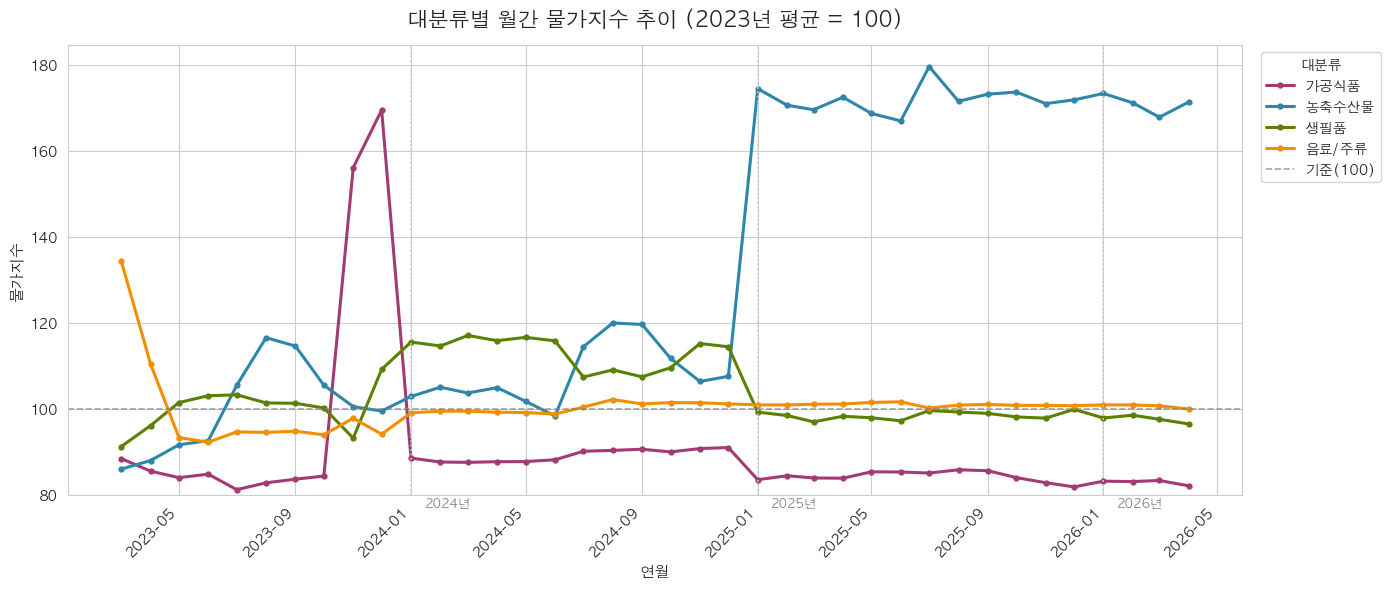

In [72]:
# 대분류별 월간 물가지수 추이
# ── 1. 월별 대분류 평균 가격 집계 ────────────────────────────────
monthly_cat = (
    df_clean
    .groupby(['연월_period', '대분류'])['보정가격']
    .mean()
    .reset_index()
)
monthly_cat.columns = ['연월', '대분류', '평균가격']
monthly_cat = monthly_cat.sort_values('연월')

# ── 2. 지수화 (2023년 평균 = 100 기준) ────────────────────────────
base_price = (
    monthly_cat[monthly_cat['연월'].dt.year == 2023]
    .groupby('대분류')['평균가격']
    .mean()
    .rename('기준가격')
)
monthly_cat = monthly_cat.merge(base_price, on='대분류', how='left')
monthly_cat['물가지수'] = (monthly_cat['평균가격'] / monthly_cat['기준가격']) * 100

# ── 3. 시각화 ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

for cat, group in monthly_cat.groupby('대분류'):
    x = group['연월'].dt.to_timestamp()
    ax.plot(
        x, group['물가지수'],
        label=cat,
        color=CATEGORY_COLORS.get(cat),
        linewidth=2.2,
        marker='o', markersize=3.5,
    )

# 기준선
ax.axhline(100, color='gray', linestyle='--', linewidth=1.2, alpha=0.7, label='기준(100)')

# 연도 구분선
for year in [2024, 2025, 2026]:
    ax.axvline(pd.Timestamp(f'{year}-01-01'), color='#cccccc',
               linestyle=':', linewidth=1.2)
    ax.text(pd.Timestamp(f'{year}-01-15'), ax.get_ylim()[0] + 1,
            f'{year}년', fontsize=9, color='gray')

ax.set_title('대분류별 월간 물가지수 추이 (2023년 평균 = 100)', fontsize=15, pad=14, fontweight='bold')
ax.set_xlabel('연월', fontsize=11)
ax.set_ylabel('물가지수', fontsize=11)
ax.legend(title='대분류', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=10)
ax.set_ylim(bottom=80)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
# plt.savefig(f'{OUTPUT_DIR}/viz_01_price_index.png', dpi=150, bbox_inches='tight')
plt.show()
# print("✅ VIZ-01 저장 완료")

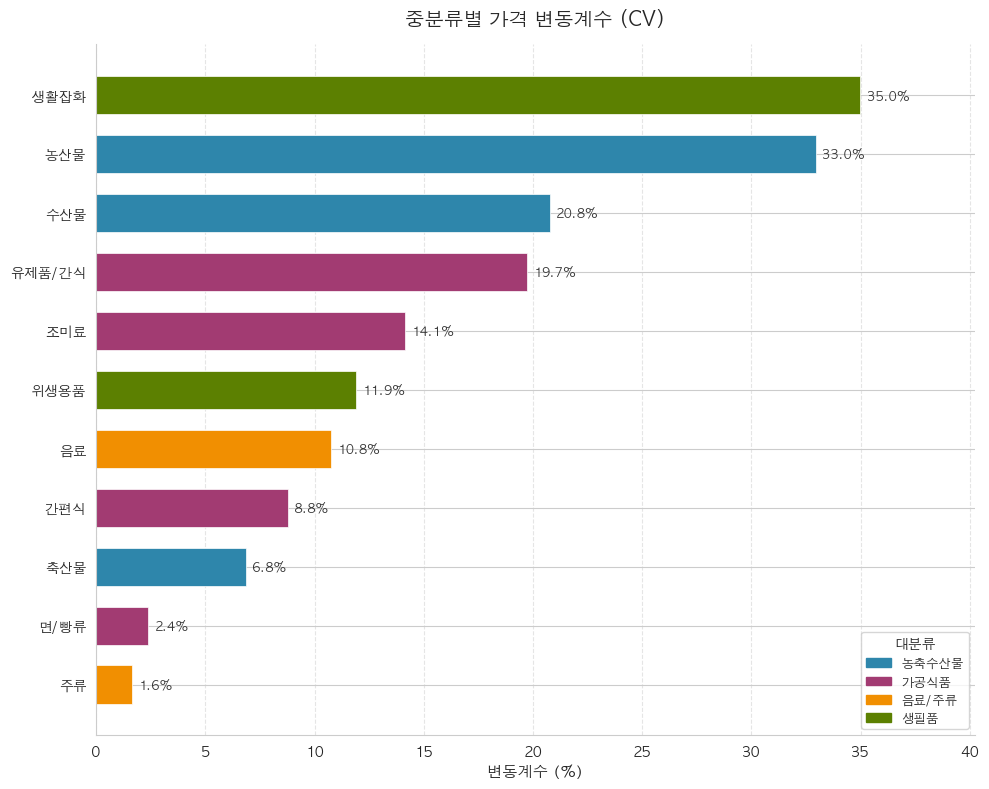

In [73]:
# 중분류별 가격 변동성 비교 (변동계수)
# ── 1. 중분류별 변동계수(CV) 계산 ────────────────────────────────
# 월 평균가격 기준으로 CV를 계산해야 단순 개별 데이터의 노이즈를 줄일 수 있음
monthly_mid = (
    df_clean
    .groupby(['연월_period', '대분류', '중분류'])['보정가격']
    .mean()
    .reset_index()
)

cv_df = (
    monthly_mid
    .groupby(['대분류', '중분류'])['보정가격']
    .agg(
        평균=  'mean',
        표준편차='std'
    )
    .reset_index()
)
cv_df['변동계수'] = (cv_df['표준편차'] / cv_df['평균'] * 100).round(2)
cv_df = cv_df.dropna(subset=['변동계수']).sort_values('변동계수', ascending=True)

# ── 2. 시각화 ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))

bars = ax.barh(
    cv_df['중분류'],
    cv_df['변동계수'],
    color=[CATEGORY_COLORS.get(c, '#888888') for c in cv_df['대분류']],
    edgecolor='white', linewidth=0.5,
    height=0.65,
)

# 값 레이블
for bar, val in zip(bars, cv_df['변동계수']):
    ax.text(
        bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
        f'{val:.1f}%', va='center', fontsize=9, color='#333333'
    )

# 범례 (대분류 색상)
from matplotlib.patches import Patch
legend_handles = [Patch(color=v, label=k) for k, v in CATEGORY_COLORS.items()]
ax.legend(handles=legend_handles, title='대분류', loc='lower right', fontsize=9)

ax.set_title('중분류별 가격 변동계수 (CV)', fontsize=14, pad=14, fontweight='bold') # 값이 클수록 가격 불안정
ax.set_xlabel('변동계수 (%)', fontsize=11)
ax.set_ylabel('')
ax.set_xlim(0, cv_df['변동계수'].max() * 1.15)
ax.grid(axis='x', linestyle='--', alpha=0.5)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
# plt.savefig(f'{OUTPUT_DIR}/viz_02_cv_by_category.png', dpi=150, bbox_inches='tight')
plt.show()
# print("✅ VIZ-02 저장 완료")

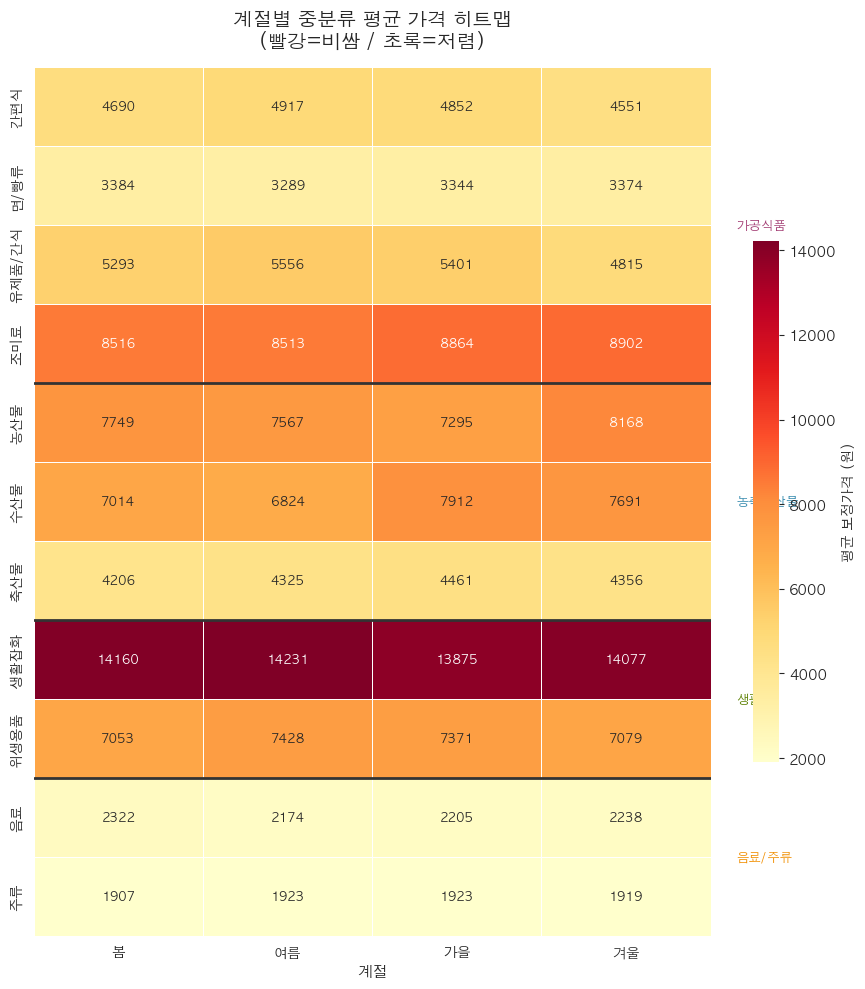

In [74]:
# 계절별 중분류 평균 가격 히트맵
# ── 1. 중분류 × 계절 평균 가격 집계 ─────────────────────────────
season_order = ['봄', '여름', '가을', '겨울']

season_mid = (
    df_clean
    .groupby(['계절', '중분류', '대분류'])['보정가격']
    .mean()
    .reset_index()
)

# 피벗: 행=중분류, 열=계절
pivot_season = (
    season_mid
    .pivot_table(index='중분류', columns='계절', values='보정가격')
    [season_order]   # 계절 순서 고정
)

# 대분류 순서대로 중분류 정렬
mid_order = (
    season_mid
    .drop_duplicates('중분류')
    .sort_values(['대분류', '중분류'])
    ['중분류']
    .tolist()
)
pivot_season = pivot_season.reindex(mid_order)

# ── 2. 시각화 ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 10))

sns.heatmap(
    pivot_season,
    ax=ax,
    cmap='YlOrRd',          # 빨강=비쌈, 노랑=저렴
    annot=True,
    fmt='.0f',
    linewidths=0.4,
    linecolor='white',
    cbar_kws={'label': '평균 보정가격 (원)', 'shrink': 0.6},
    annot_kws={'size': 9},
)

# 대분류 구분선 추가
category_counts = (
    season_mid.drop_duplicates('중분류')
    .sort_values(['대분류', '중분류'])
    .groupby('대분류', sort=False)
    .size()
    .cumsum()
    .tolist()
)
for boundary in category_counts[:-1]:
    ax.axhline(boundary, color='#333333', linewidth=2)

# 대분류 레이블 (우측)
category_labels = (
    season_mid.drop_duplicates('중분류')
    .sort_values(['대분류', '중분류'])
    .groupby('대분류', sort=False)
    .size()
)
cumsum = 0
for cat, cnt in category_labels.items():
    mid_y = cumsum + cnt / 2
    ax.text(
        4.15, mid_y,
        cat,
        va='center', ha='left', fontsize=9,
        color=CATEGORY_COLORS.get(cat, '#333333'),
        fontweight='bold',
    )
    cumsum += cnt

ax.set_title('계절별 중분류 평균 가격 히트맵\n(빨강=비쌈 / 초록=저렴)', 
             fontsize=14, pad=14, fontweight='bold')
ax.set_xlabel('계절', fontsize=11)
ax.set_ylabel('')

plt.tight_layout()
# plt.savefig(f'{OUTPUT_DIR}/viz_03_season_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
# print("✅ VIZ-03 저장 완료")

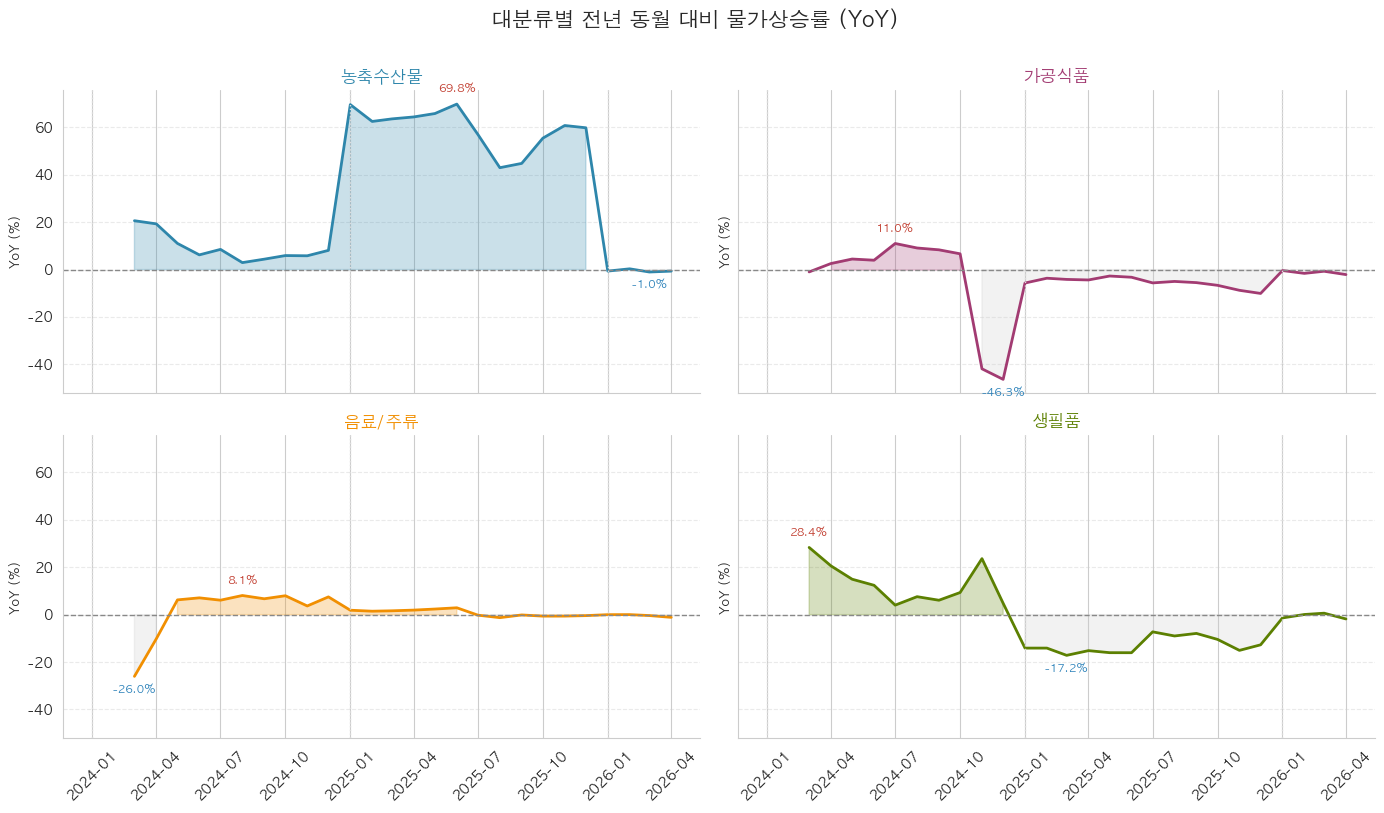

In [75]:
# 대분류별 YoY (전년 동월 대비) 물가상승률
# ── 1. 월별 대분류 평균 집계 ──────────────────────────────────────
monthly_yoy = (
    df_clean
    .groupby(['연월_period', '대분류'])['보정가격']
    .mean()
    .unstack('대분류')   # 열 = 대분류
    .sort_index()
)

# ── 2. YoY 계산 (컬럼별로 dropna 적용해 빈 차트 방지) ───────────
yoy_df = monthly_yoy.pct_change(periods=12) * 100

# ── 3. 시각화 ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)
axes = axes.flatten()
categories = list(CATEGORY_COLORS.keys())

for ax, cat in zip(axes, categories):
    if cat not in yoy_df.columns:
        ax.set_visible(False)
        continue

    series = yoy_df[cat].dropna()
    x = series.index.to_timestamp()
    y = series.values

    # 양수/음수 영역 채우기
    ax.fill_between(x, y, 0,
                    where=(y >= 0), alpha=0.25,
                    color=CATEGORY_COLORS[cat], label='상승')
    ax.fill_between(x, y, 0,
                    where=(y < 0), alpha=0.25,
                    color='#cccccc', label='하락')

    ax.plot(x, y, color=CATEGORY_COLORS[cat], linewidth=2)
    ax.axhline(0, color='#888888', linewidth=1, linestyle='--')

    # 연도 구분선
    for year in [2024, 2025, 2026]:
        ax.axvline(pd.Timestamp(f'{year}-01-01'),
                   color='#dddddd', linestyle=':', linewidth=1)

    # 최대/최소 포인트 표시
    if len(y) > 0:
        max_idx = series.idxmax()
        min_idx = series.idxmin()
        ax.annotate(f'{series[max_idx]:.1f}%',
                    xy=(max_idx.to_timestamp(), series[max_idx]),
                    xytext=(0, 8), textcoords='offset points',
                    fontsize=8, ha='center', color='#c0392b')
        ax.annotate(f'{series[min_idx]:.1f}%',
                    xy=(min_idx.to_timestamp(), series[min_idx]),
                    xytext=(0, -12), textcoords='offset points',
                    fontsize=8, ha='center', color='#2980b9')

    ax.set_title(cat, fontsize=12, fontweight='bold',
                 color=CATEGORY_COLORS[cat])
    ax.set_ylabel('YoY (%)', fontsize=9)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('대분류별 전년 동월 대비 물가상승률 (YoY)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
# plt.savefig(f'{OUTPUT_DIR}/viz_04_yoy_by_category.png', dpi=150, bbox_inches='tight')
plt.show()
# print("✅ VIZ-04 저장 완료")

In [76]:
# 사전 확인 코드
print(df_clean[df_clean['대표품목명'].isin(TARGET_ITEMS)]['대표품목명'].unique())

<StringArray>
['식용유', '고등어', '계란', '돼지고기', '소고기', '배추', '라면', '쌀']
Length: 8, dtype: str


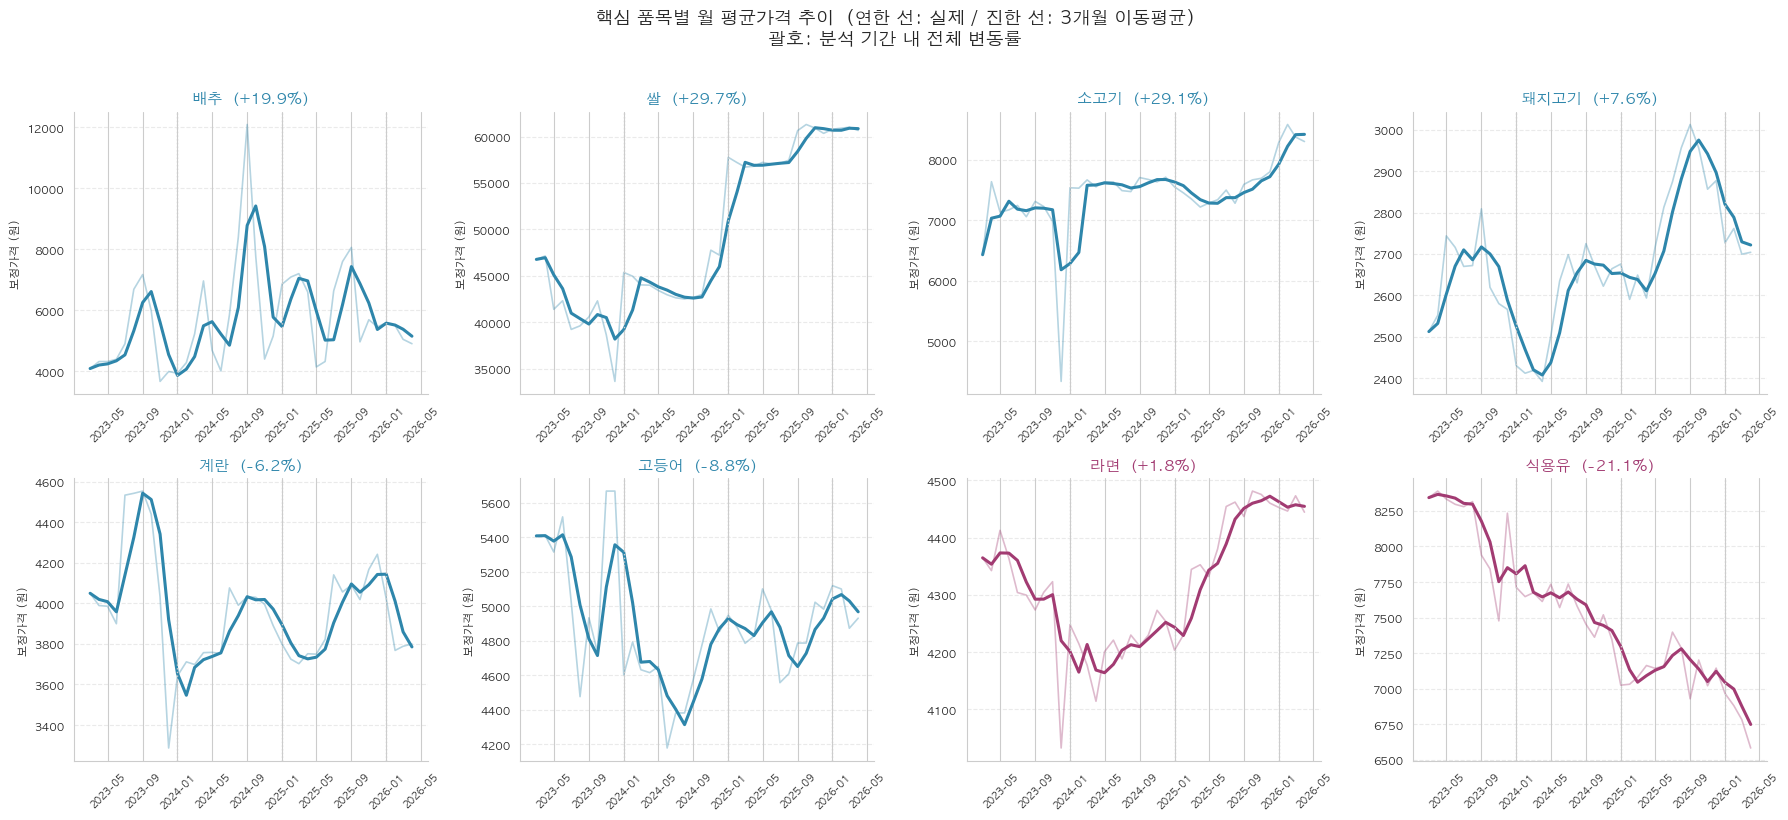

In [77]:
# 핵심 품목별 시계열 + 3개월 이동평균
# ── 1. 분석 대상 품목 및 순서 ─────────────────────────────────────
TARGET_ITEMS = ['배추', '쌀', '소고기', '돼지고기', '계란', '고등어', '라면', '식용유']

# ── 2. 품목별 월 평균가격 집계 ────────────────────────────────────
item_monthly = (
    df_clean[df_clean['대표품목명'].isin(TARGET_ITEMS)]
    .groupby(['연월_period', '대표품목명'])['보정가격']
    .mean()
    .reset_index()
    .sort_values('연월_period')
)

# 3개월 이동평균 계산
item_monthly['이동평균'] = (
    item_monthly
    .groupby('대표품목명')['보정가격']
    .transform(lambda x: x.rolling(3, min_periods=1).mean())
)

# ── 3. 시각화 (2×4 subplot) ───────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for ax, item in zip(axes, TARGET_ITEMS):
    data = item_monthly[item_monthly['대표품목명'] == item]

    if data.empty:
        ax.set_visible(False)
        continue

    x = data['연월_period'].dt.to_timestamp()

    # 대분류 색상 가져오기
    cat = df_clean[df_clean['대표품목명'] == item]['대분류'].iloc[0]
    color = CATEGORY_COLORS.get(cat, '#888888')

    # 실제 가격 (연하게)
    ax.plot(x, data['보정가격'],
            color=color, alpha=0.35, linewidth=1.2, linestyle='-')

    # 이동평균 (진하게)
    ax.plot(x, data['이동평균'],
            color=color, linewidth=2.2, label='3개월 이동평균')

    # 연도 구분선
    for year in [2024, 2025, 2026]:
        ax.axvline(pd.Timestamp(f'{year}-01-01'),
                   color='#cccccc', linestyle=':', linewidth=1)

    # 최신값 표시
    latest_val = data['보정가격'].iloc[-1]
    first_val  = data['보정가격'].iloc[0]
    change_pct = (latest_val - first_val) / first_val * 100
    sign = '+' if change_pct >= 0 else ''
    ax.set_title(f'{item}  ({sign}{change_pct:.1f}%)',
                 fontsize=11, fontweight='bold', color=color)

    ax.set_ylabel('보정가격 (원)', fontsize=8)
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', labelsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('핵심 품목별 월 평균가격 추이  (연한 선: 실제 / 진한 선: 3개월 이동평균)\n괄호: 분석 기간 내 전체 변동률',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
# plt.savefig(f'{OUTPUT_DIR}/viz_05_item_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
# print("✅ VIZ-05 저장 완료")

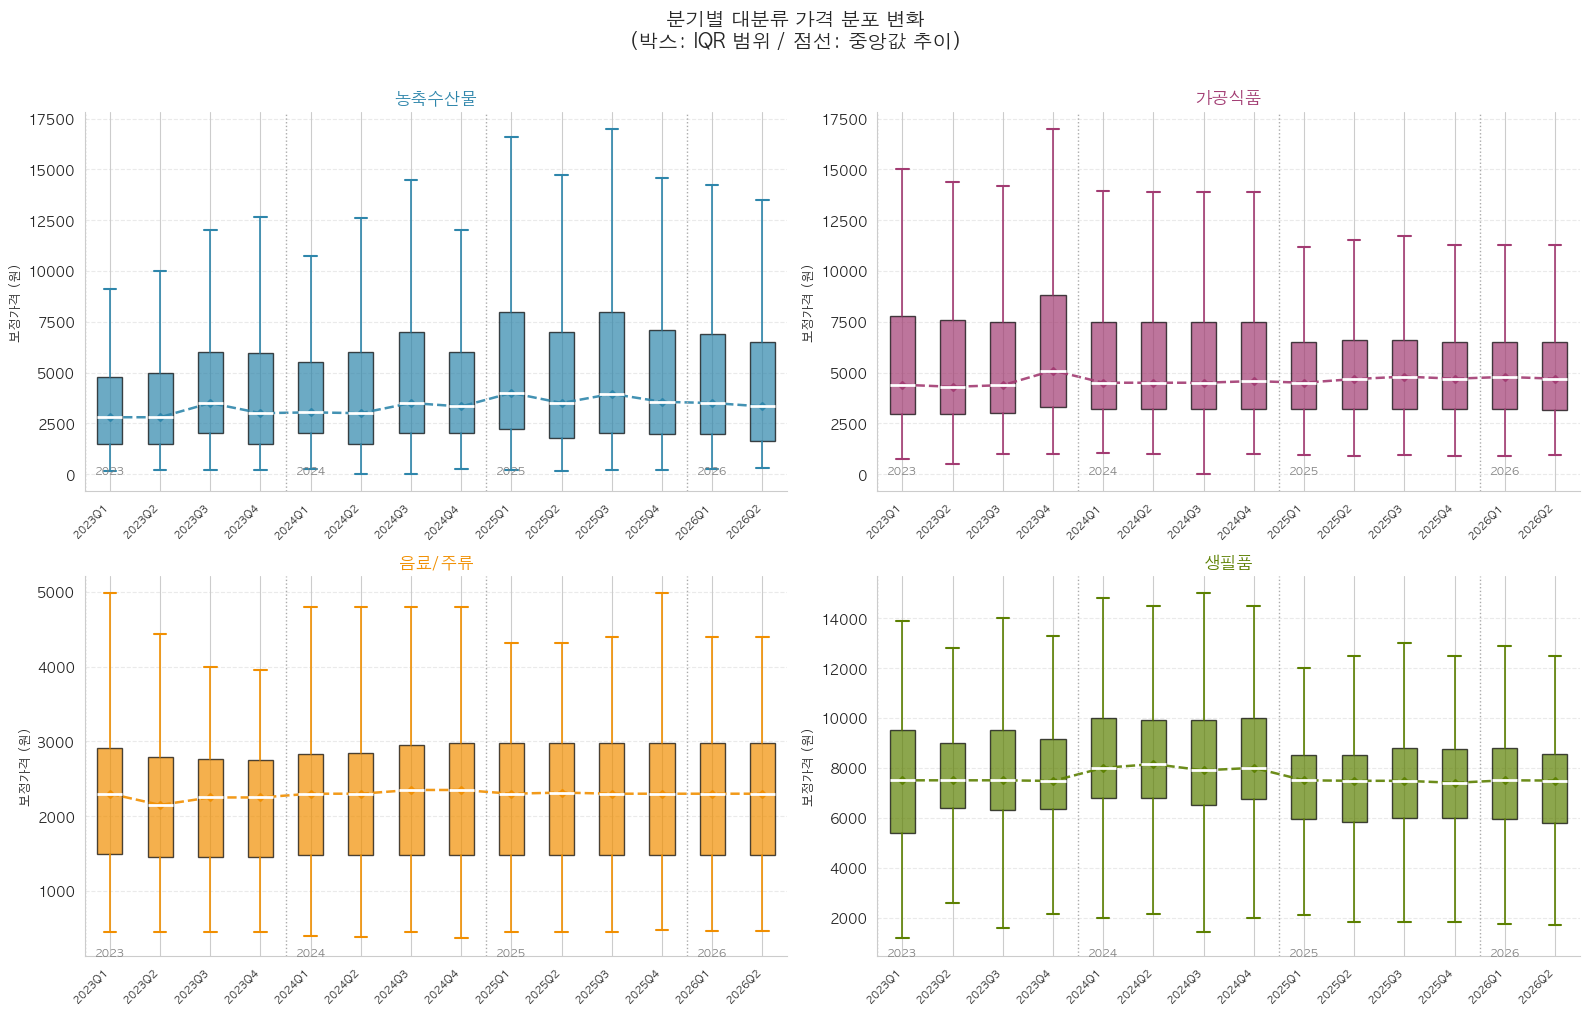

In [78]:
# 분기별 대분류 가격 박스플롯
# ── 1. 연도-분기 레이블 생성 ──────────────────────────────────────
df_clean['연도분기'] = (
    df_clean['점검일자'].dt.year.astype(str) + 'Q' +
    df_clean['분기'].astype(str)
)
quarter_order = sorted(df_clean['연도분기'].unique())

# ── 2. 시각화 (대분류별 subplot) ──────────────────────────────────
categories = list(CATEGORY_COLORS.keys())
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=False)
axes = axes.flatten()

for ax, cat in zip(axes, categories):
    data = df_clean[df_clean['대분류'] == cat]
    color = CATEGORY_COLORS[cat]

    # 분기별 데이터 준비
    box_data = [
        data[data['연도분기'] == q]['보정가격'].dropna().values
        for q in quarter_order
    ]
    box_data_filtered = [(q, d) for q, d in zip(quarter_order, box_data) if len(d) > 0]
    labels, values = zip(*box_data_filtered)

    bp = ax.boxplot(
        values,
        patch_artist=True,
        showfliers=False,      # 이상치 점 숨김 (IQR 미처리 상태 고려)
        medianprops=dict(color='white', linewidth=2),
        boxprops=dict(facecolor=color, alpha=0.7),
        whiskerprops=dict(color=color, linewidth=1.2),
        capprops=dict(color=color, linewidth=1.5),
    )

    # 중앙값 추이 연결선
    medians = [np.median(v) for v in values]
    ax.plot(range(1, len(medians) + 1), medians,
            color=color, linewidth=1.8, linestyle='--',
            marker='D', markersize=4, alpha=0.9)

    # 연도 구분선 (Q1 시작 위치)
    for i, label in enumerate(labels):
        if label.endswith('Q1'):
            ax.axvline(i + 1 - 0.5, color='#aaaaaa', linestyle=':', linewidth=1)
            year = label[:4]
            ax.text(i + 1, ax.get_ylim()[0] if ax.get_ylim()[0] > 0 else 0,
                    year, fontsize=8, color='gray', ha='center')

    ax.set_title(cat, fontsize=12, fontweight='bold', color=color)
    ax.set_xticks(range(1, len(labels) + 1))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=7.5)
    ax.set_ylabel('보정가격 (원)', fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('분기별 대분류 가격 분포 변화\n(박스: IQR 범위 / 점선: 중앙값 추이)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
# plt.savefig(f'{OUTPUT_DIR}/viz_06_quarterly_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
# print("✅ VIZ-06 저장 완료")

### 시계열 패턴

#### 대분류별 월별 물가지수 추이

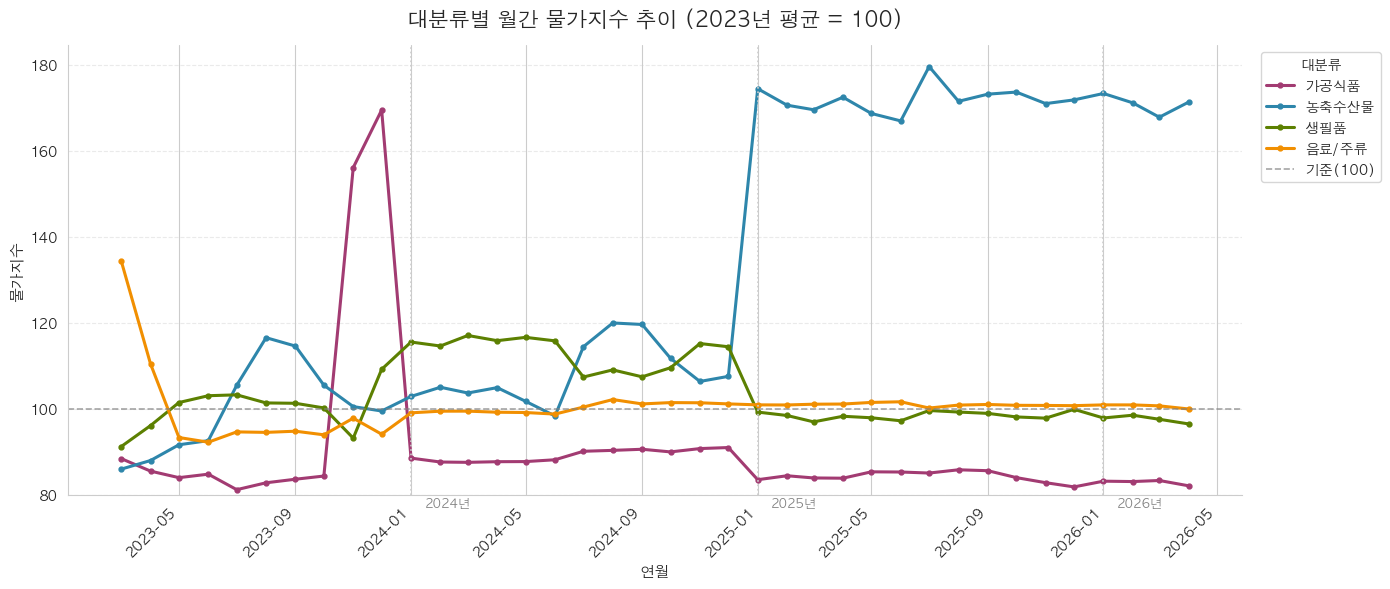

In [79]:
# ── 1. 월별 대분류 평균 집계 ──────────────────────────────────────
monthly_cat = (
    df_clean
    .groupby(['연월_period', '대분류'])['보정가격']
    .mean()
    .reset_index()
)
monthly_cat.columns = ['연월', '대분류', '평균가격']
monthly_cat = monthly_cat.sort_values('연월')

# ── 2. 지수화 (2023년 평균 = 100 기준) ────────────────────────────
base_price = (
    monthly_cat[monthly_cat['연월'].dt.year == 2023]
    .groupby('대분류')['평균가격']
    .mean()
    .rename('기준가격')
)
monthly_cat = monthly_cat.merge(base_price, on='대분류', how='left')
monthly_cat['물가지수'] = (monthly_cat['평균가격'] / monthly_cat['기준가격']) * 100

# ── 3. 시각화 ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

for cat, group in monthly_cat.groupby('대분류'):
    x = group['연월'].dt.to_timestamp()
    ax.plot(x, group['물가지수'],
            label=cat, color=CATEGORY_COLORS.get(cat),
            linewidth=2.2, marker='o', markersize=3.5)

ax.axhline(100, color='gray', linestyle='--', linewidth=1.2, alpha=0.7, label='기준(100)')

for year in [2024, 2025, 2026]:
    ax.axvline(pd.Timestamp(f'{year}-01-01'),
               color='#cccccc', linestyle=':', linewidth=1.2)
    ax.text(pd.Timestamp(f'{year}-01-15'), ax.get_ylim()[0] + 1,
            f'{year}년', fontsize=9, color='gray')

ax.set_title('대분류별 월간 물가지수 추이 (2023년 평균 = 100)',
             fontsize=15, pad=14, fontweight='bold')
ax.set_xlabel('연월', fontsize=11)
ax.set_ylabel('물가지수', fontsize=11)
ax.legend(title='대분류', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=10)
ax.set_ylim(bottom=80)
plt.xticks(rotation=45, ha='right')
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
# plt.savefig(f'{OUTPUT_DIR}/viz_01_price_index.png', dpi=150, bbox_inches='tight')
plt.show()
# print("✅ VIZ-01 저장 완료")

#### 대분류별 YoY 물가상승률

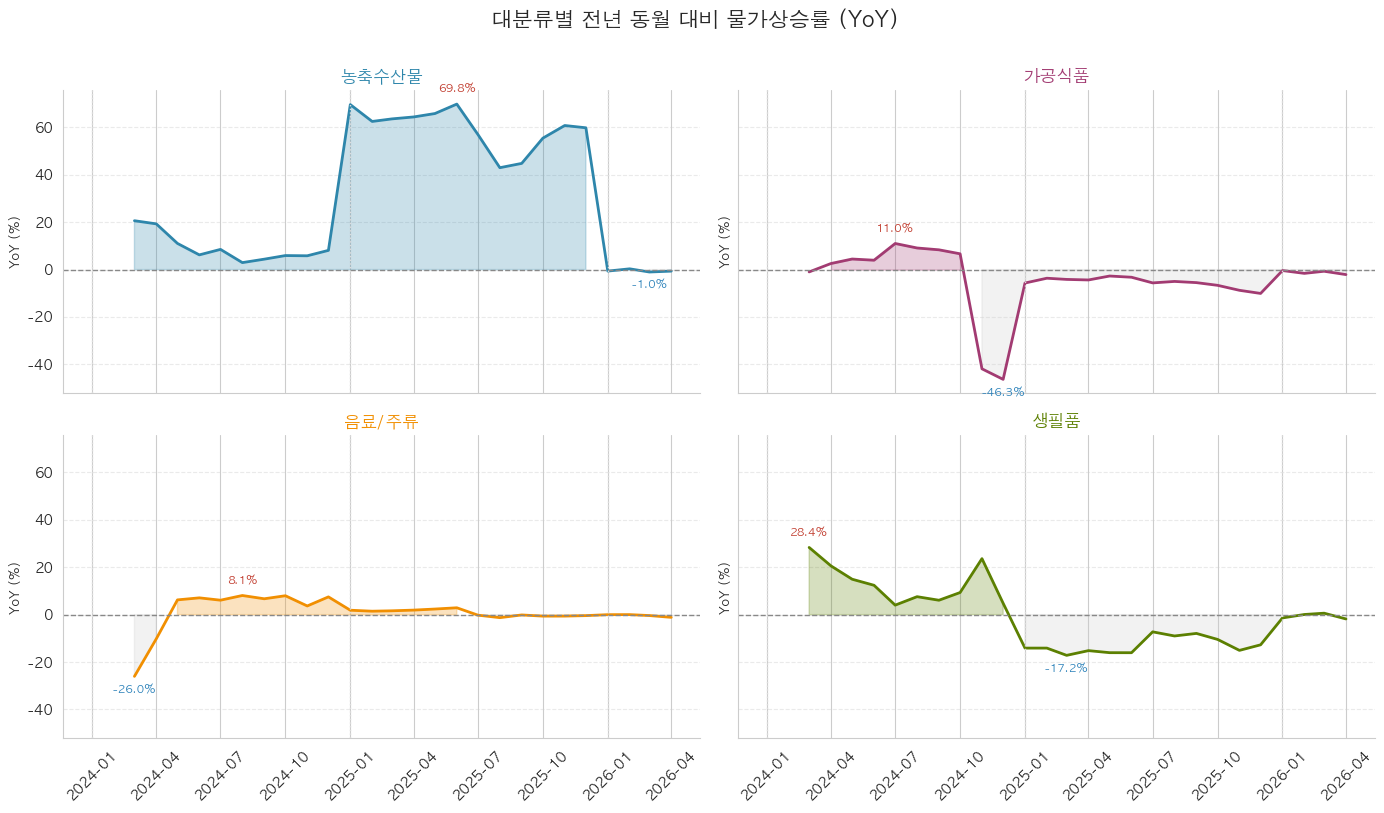

In [80]:
# ── 1. 월별 대분류 평균 집계 → YoY 계산 ─────────────────────────
# pct_change(12)는 행 위치 기준이므로 컬럼별 dropna()로 빈 차트 방지
monthly_yoy = (
    df_clean
    .groupby(['연월_period', '대분류'])['보정가격']
    .mean()
    .unstack('대분류')
    .sort_index()
)
yoy_df = monthly_yoy.pct_change(periods=12) * 100

# ── 2. 대분류별 2×2 subplot ──────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)
axes = axes.flatten()
categories = list(CATEGORY_COLORS.keys())

for ax, cat in zip(axes, categories):
    if cat not in yoy_df.columns:
        ax.set_visible(False)
        continue

    series = yoy_df[cat].dropna()
    x = series.index.to_timestamp()
    y = series.values

    ax.fill_between(x, y, 0, where=(y >= 0), alpha=0.25,
                    color=CATEGORY_COLORS[cat])
    ax.fill_between(x, y, 0, where=(y < 0),  alpha=0.25, color='#cccccc')
    ax.plot(x, y, color=CATEGORY_COLORS[cat], linewidth=2)
    ax.axhline(0, color='#888888', linewidth=1, linestyle='--')

    for year in [2024, 2025, 2026]:
        ax.axvline(pd.Timestamp(f'{year}-01-01'),
                   color='#dddddd', linestyle=':', linewidth=1)

    if len(y) > 0:
        max_idx = series.idxmax()
        min_idx = series.idxmin()
        ax.annotate(f'{series[max_idx]:.1f}%',
                    xy=(max_idx.to_timestamp(), series[max_idx]),
                    xytext=(0, 8), textcoords='offset points',
                    fontsize=8, ha='center', color='#c0392b')
        ax.annotate(f'{series[min_idx]:.1f}%',
                    xy=(min_idx.to_timestamp(), series[min_idx]),
                    xytext=(0, -12), textcoords='offset points',
                    fontsize=8, ha='center', color='#2980b9')

    ax.set_title(cat, fontsize=12, fontweight='bold',
                 color=CATEGORY_COLORS[cat])
    ax.set_ylabel('YoY (%)', fontsize=9)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('대분류별 전년 동월 대비 물가상승률 (YoY)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
# plt.savefig(f'{OUTPUT_DIR}/viz_04_yoy_by_category.png', dpi=150, bbox_inches='tight')
plt.show()
# print("✅ VIZ-04 저장 완료")

#### 핵심 품목별 시계열여 & 3개월 이동평균

In [81]:
# 핵심 품목 선정 및 해당 품목명이 실제 칼럼값과 일치하는지 먼저 확인
TARGET_ITEMS = ['배추', '쌀', '소고기', '돼지고기', '계란', '고등어', '라면', '식용유']
found = df_clean[df_clean['대표품목명'].isin(TARGET_ITEMS)]['대표품목명'].unique()
missing = set(TARGET_ITEMS) - set(found)
if missing:
    print(f"⚠️  미존재 품목: {missing}  →  TARGET_ITEMS에서 제거 후 실행하세요")
else:
    print(f"✅ 품목 확인 완료: {sorted(found)}")

✅ 품목 확인 완료: ['계란', '고등어', '돼지고기', '라면', '배추', '소고기', '식용유', '쌀']


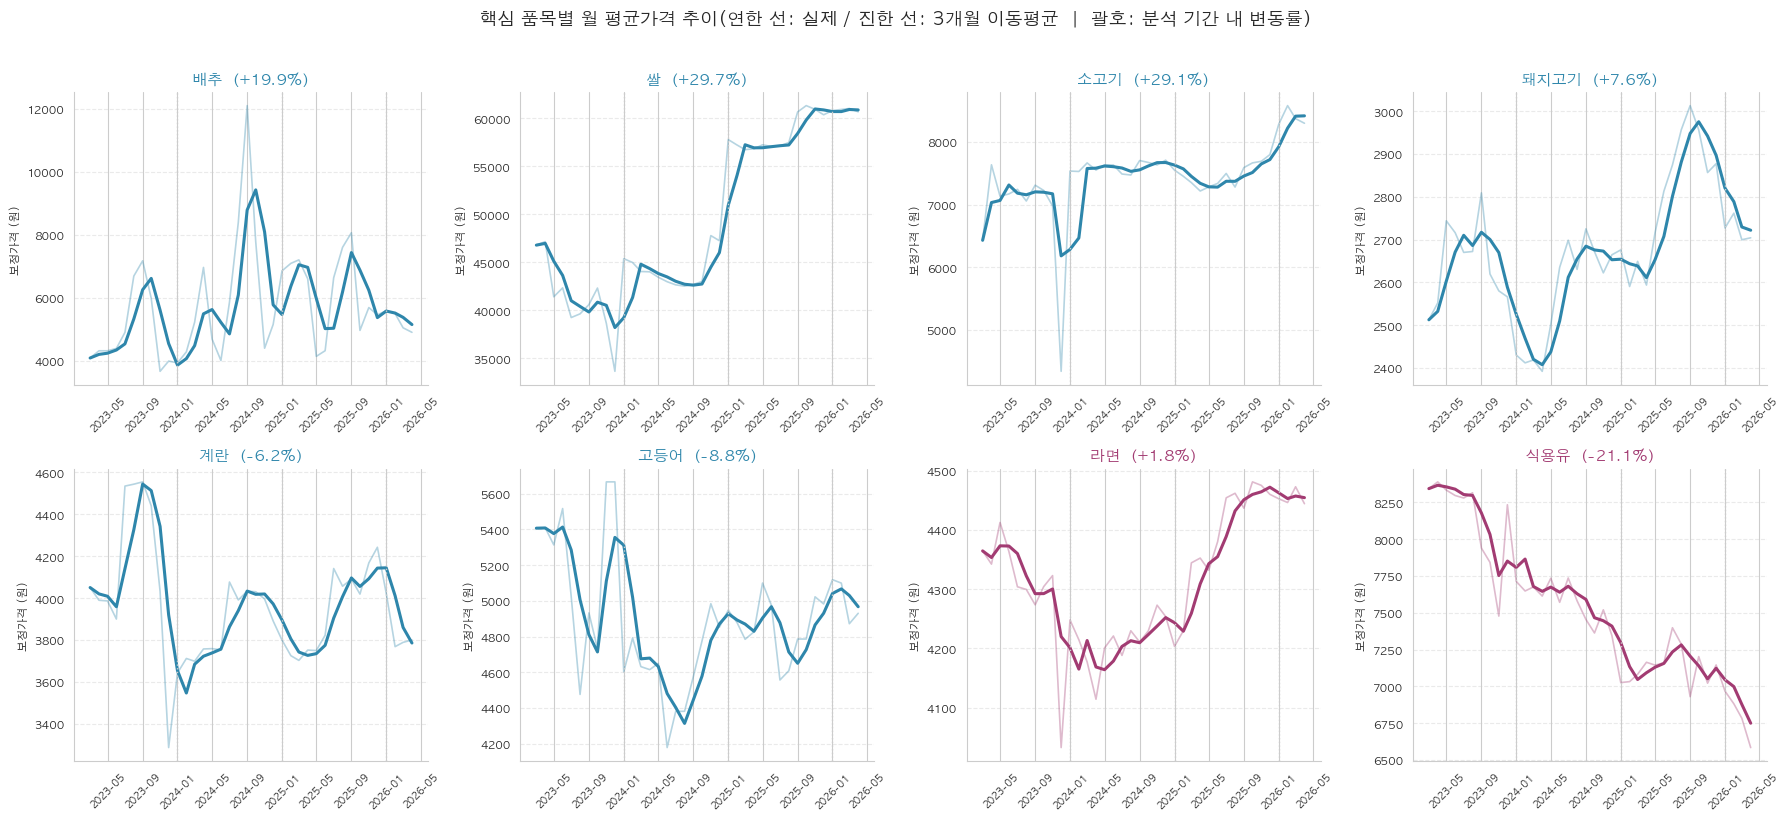

In [82]:
# ── 1. 품목별 월 평균가격 + 3개월 이동평균 ───────────────────────
item_monthly = (
    df_clean[df_clean['대표품목명'].isin(TARGET_ITEMS)]
    .groupby(['연월_period', '대표품목명'])['보정가격']
    .mean()
    .reset_index()
    .sort_values('연월_period')
)
item_monthly['이동평균'] = (
    item_monthly
    .groupby('대표품목명')['보정가격']
    .transform(lambda x: x.rolling(3, min_periods=1).mean())
)

# ── 2. 2×4 subplot ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for ax, item in zip(axes, TARGET_ITEMS):
    data = item_monthly[item_monthly['대표품목명'] == item]
    if data.empty:
        ax.set_visible(False)
        continue

    x = data['연월_period'].dt.to_timestamp()
    cat   = df_clean[df_clean['대표품목명'] == item]['대분류'].iloc[0]
    color = CATEGORY_COLORS.get(cat, '#888888')

    ax.plot(x, data['보정가격'],
            color=color, alpha=0.35, linewidth=1.2)       # 실제가격 (연하게)
    ax.plot(x, data['이동평균'],
            color=color, linewidth=2.2, label='3개월 이동평균')  # 이동평균 (진하게)

    for year in [2024, 2025, 2026]:
        ax.axvline(pd.Timestamp(f'{year}-01-01'),
                   color='#cccccc', linestyle=':', linewidth=1)

    first_val  = data['보정가격'].iloc[0]
    latest_val = data['보정가격'].iloc[-1]
    change_pct = (latest_val - first_val) / first_val * 100
    sign = '+' if change_pct >= 0 else ''

    ax.set_title(f'{item}  ({sign}{change_pct:.1f}%)',
                 fontsize=11, fontweight='bold', color=color)
    ax.set_ylabel('보정가격 (원)', fontsize=8)
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', labelsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle(
    '핵심 품목별 월 평균가격 추이'
    '(연한 선: 실제 / 진한 선: 3개월 이동평균  |  괄호: 분석 기간 내 변동률)',
    fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
# plt.savefig(f'{OUTPUT_DIR}/viz_05_item_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
# print("✅ VIZ-05 저장 완료")

### 계절성 및 분기 패턴

#### 계절별 중분류 평균 가격 (히트맵)

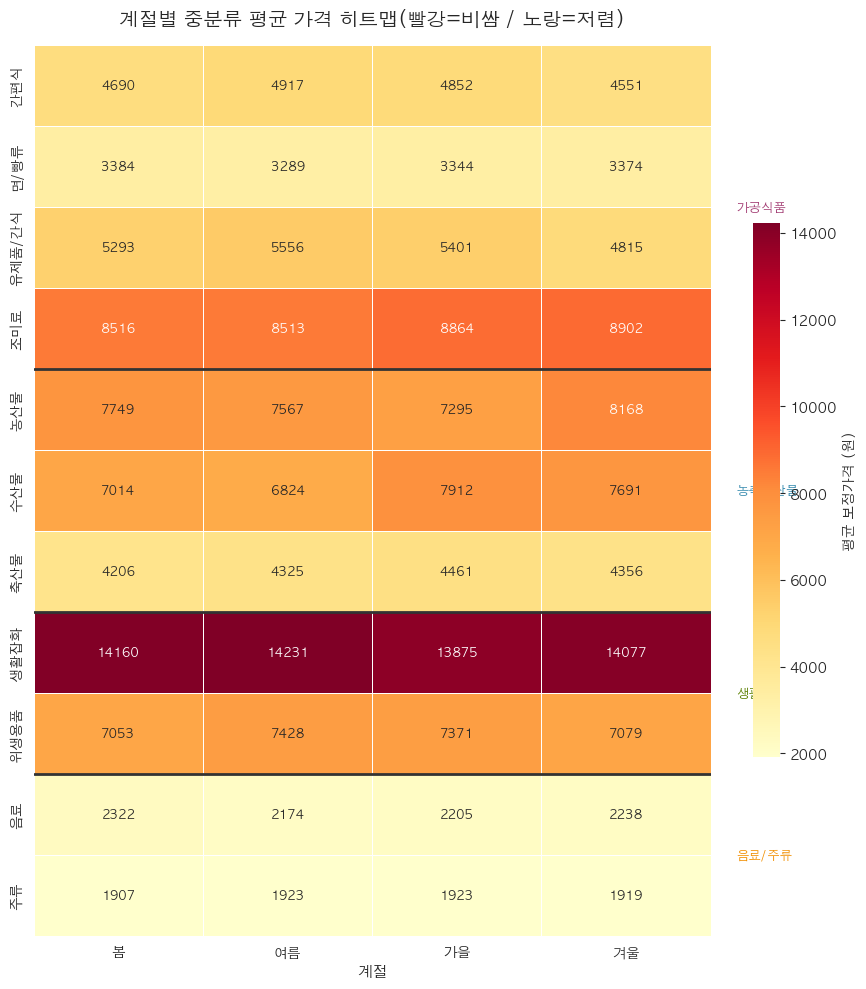

In [ ]:
season_order = ['봄', '여름', '가을', '겨울']

# ── 1. 중분류 × 계절 평균가격 집계 ───────────────────────────────
season_mid = (
    df_clean
    .groupby(['계절', '중분류', '대분류'])['보정가격']
    .mean()
    .reset_index()
)

# ── 2. 피벗 + 대분류 기준 정렬 ────────────────────────────────────
pivot_season = (
    season_mid
    .pivot_table(index='중분류', columns='계절', values='보정가격')
    [season_order]
)
mid_order = (
    season_mid.drop_duplicates('중분류')
    .sort_values(['대분류', '중분류'])['중분류'].tolist()
)
pivot_season = pivot_season.reindex(mid_order)

# ── 3. 시각화 ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 10))

sns.heatmap(
    pivot_season, ax=ax,
    cmap='YlOrRd',
    annot=True, fmt='.0f',
    linewidths=0.4, linecolor='white',
    cbar_kws={'label': '평균 보정가격 (원)', 'shrink': 0.6},
    annot_kws={'size': 9},
)

# 대분류 구분선
category_counts = (
    season_mid.drop_duplicates('중분류')
    .sort_values(['대분류', '중분류'])
    .groupby('대분류', sort=False).size()
    .cumsum().tolist()
)
for boundary in category_counts[:-1]:
    ax.axhline(boundary, color='#333333', linewidth=2)

# 대분류 레이블 (우측)
cumsum = 0
for cat, cnt in (
    season_mid.drop_duplicates('중분류')
    .sort_values(['대분류', '중분류'])
    .groupby('대분류', sort=False).size().items()
):
    ax.text(4.15, cumsum + cnt / 2, cat,
            va='center', ha='left', fontsize=9,
            color=CATEGORY_COLORS.get(cat, '#333333'), fontweight='bold')
    cumsum += cnt

# 열 헤더 색상
for tick in ax.get_xticklabels():
    tick.set_fontweight('bold')

ax.set_title('계절별 중분류 평균 가격 히트맵 (빨강=비쌈 / 노랑=저렴)',
             fontsize=14, pad=14, fontweight='bold')
ax.set_xlabel('계절', fontsize=11)
ax.set_ylabel('')

plt.tight_layout()
# plt.savefig(f'{OUTPUT_DIR}/viz_03_season_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
# print("✅ VIZ-03 저장 완료")

#### 분기별 대분류 가격 (박스플롯)

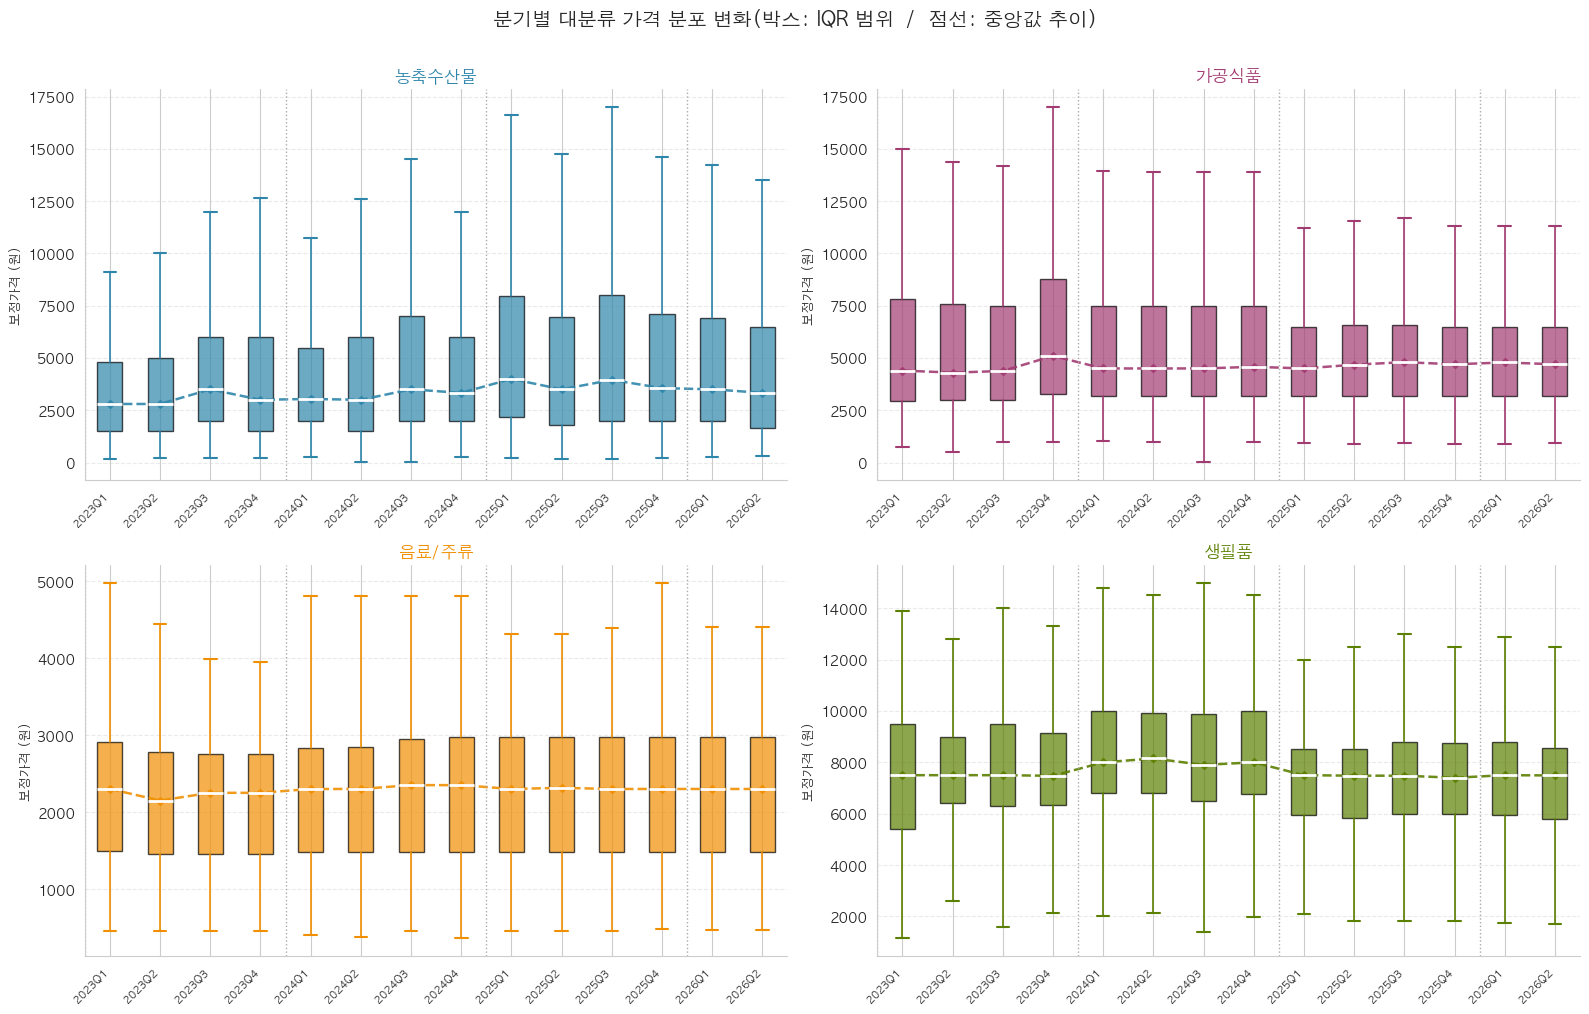

In [84]:
# ── 1. 연도-분기 레이블 생성 ──────────────────────────────────────
df_clean['연도분기'] = (
    df_clean['점검일자'].dt.year.astype(str) + 'Q' +
    df_clean['분기'].astype(str)
)
quarter_order = sorted(df_clean['연도분기'].unique())

# ── 2. 대분류별 2×2 subplot ───────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=False)
axes = axes.flatten()

for ax, cat in zip(axes, list(CATEGORY_COLORS.keys())):
    data  = df_clean[df_clean['대분류'] == cat]
    color = CATEGORY_COLORS[cat]

    box_data = [
        data[data['연도분기'] == q]['보정가격'].dropna().values
        for q in quarter_order
    ]
    filtered = [(q, d) for q, d in zip(quarter_order, box_data) if len(d) > 0]
    if not filtered:
        continue
    labels, values = zip(*filtered)

    ax.boxplot(
        values,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color='white', linewidth=2),
        boxprops=dict(facecolor=color, alpha=0.7),
        whiskerprops=dict(color=color, linewidth=1.2),
        capprops=dict(color=color, linewidth=1.5),
    )

    # 중앙값 추이선
    medians = [np.median(v) for v in values]
    ax.plot(range(1, len(medians) + 1), medians,
            color=color, linewidth=1.8, linestyle='--',
            marker='D', markersize=4, alpha=0.9)

    # 연도 구분선
    for i, label in enumerate(labels):
        if label.endswith('Q1'):
            ax.axvline(i + 1 - 0.5, color='#aaaaaa', linestyle=':', linewidth=1)

    ax.set_title(cat, fontsize=12, fontweight='bold', color=color)
    ax.set_xticks(range(1, len(labels) + 1))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=7.5)
    ax.set_ylabel('보정가격 (원)', fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('분기별 대분류 가격 분포 변화(박스: IQR 범위  /  점선: 중앙값 추이)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
# plt.savefig(f'{OUTPUT_DIR}/viz_06_quarterly_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
# print("✅ VIZ-06 저장 완료")

### 가격변동성

#### 중분류별 가격변동성

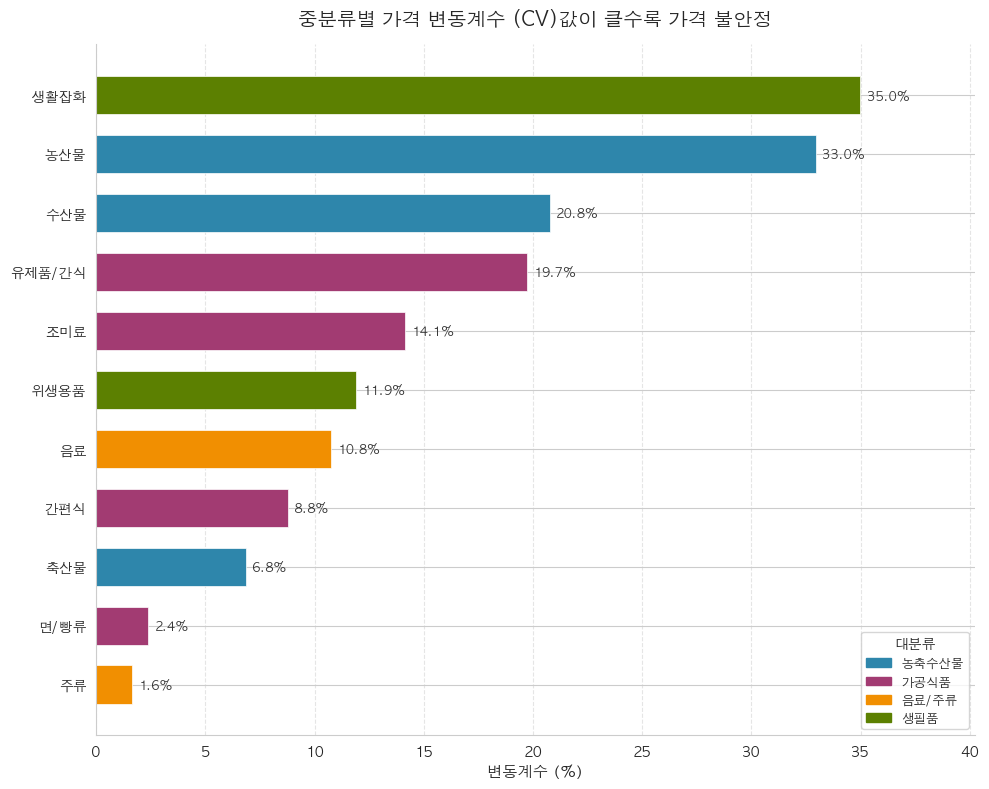

In [85]:
# ── 1. 월 평균 기준 중분류별 변동계수(CV) 계산 ────────────────────
# 개별 데이터가 아닌 월 평균 기준으로 CV 계산 → 단기 노이즈 제거
monthly_mid = (
    df_clean
    .groupby(['연월_period', '대분류', '중분류'])['보정가격']
    .mean()
    .reset_index()
)

cv_df = (
    monthly_mid
    .groupby(['대분류', '중분류'])['보정가격']
    .agg(평균='mean', 표준편차='std')
    .reset_index()
)
cv_df['변동계수'] = (cv_df['표준편차'] / cv_df['평균'] * 100).round(2)
cv_df = cv_df.dropna(subset=['변동계수']).sort_values('변동계수', ascending=True)

# ── 2. 시각화 ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))

bars = ax.barh(
    cv_df['중분류'], cv_df['변동계수'],
    color=[CATEGORY_COLORS.get(c, '#888888') for c in cv_df['대분류']],
    edgecolor='white', linewidth=0.5, height=0.65,
)

for bar, val in zip(bars, cv_df['변동계수']):
    ax.text(bar.get_width() + 0.3,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=9, color='#333333')

legend_handles = [Patch(color=v, label=k) for k, v in CATEGORY_COLORS.items()]
ax.legend(handles=legend_handles, title='대분류', loc='lower right', fontsize=9)

ax.set_title('중분류별 가격 변동계수 (CV)값이 클수록 가격 불안정',
             fontsize=14, pad=14, fontweight='bold')
ax.set_xlabel('변동계수 (%)', fontsize=11)
ax.set_xlim(0, cv_df['변동계수'].max() * 1.15)
ax.grid(axis='x', linestyle='--', alpha=0.5)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
# plt.savefig(f'{OUTPUT_DIR}/viz_02_cv_by_category.png', dpi=150, bbox_inches='tight')
plt.show()
# print("✅ VIZ-02 저장 완료")

### 지역별

#### 서울시 지역구별 종합 물가(대분류 기준) 추이

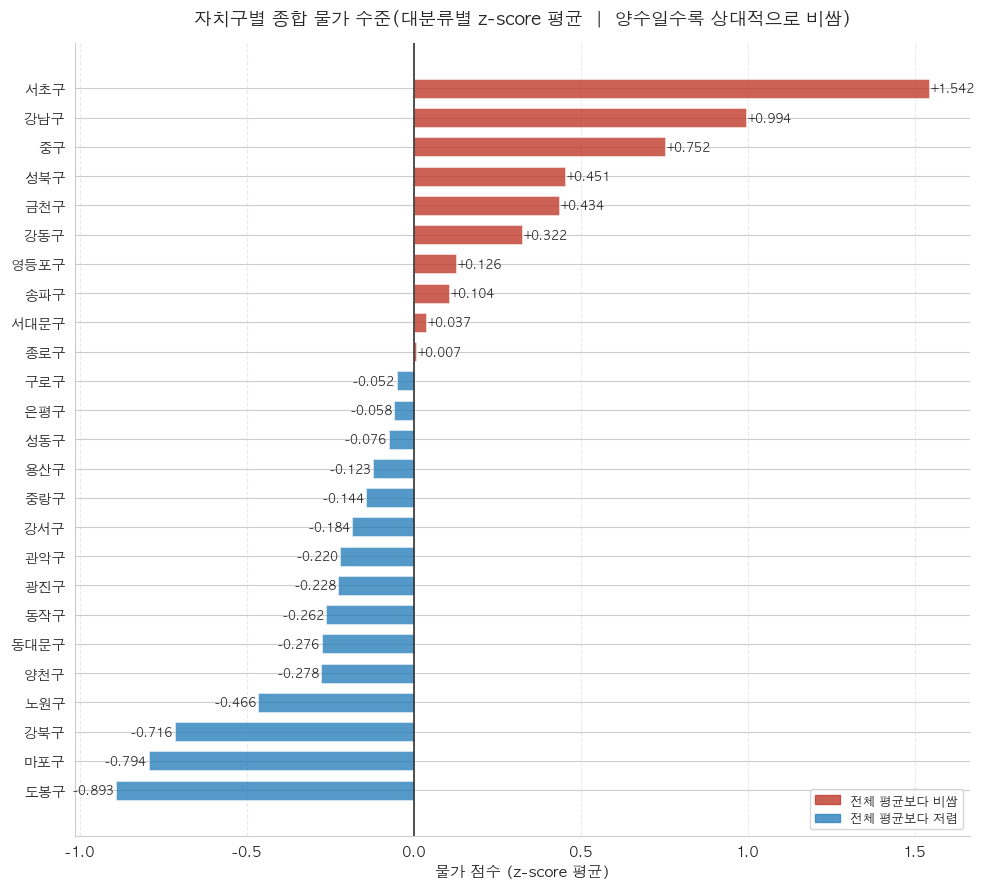

In [86]:
# ── 1. 자치구 × 대분류 평균가격 집계 ─────────────────────────────
# 품목 단가 편차 왜곡 방지: 대분류별 z-score 표준화 후 평균
district_cat = (
    df_clean
    .groupby(['자치구', '대분류'])['보정가격']
    .mean()
    .reset_index()
)
district_cat['z_score'] = (
    district_cat.groupby('대분류')['보정가격']
    .transform(lambda x: (x - x.mean()) / x.std())
)

district_score = (
    district_cat
    .groupby('자치구')['z_score']
    .mean()
    .reset_index()
    .rename(columns={'z_score': '물가점수'})
    .sort_values('물가점수', ascending=True)
)

# ── 2. 시각화 ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 9))

colors_bar = ['#c0392b' if v > 0 else '#2980b9' for v in district_score['물가점수']]
bars = ax.barh(
    district_score['자치구'], district_score['물가점수'],
    color=colors_bar, alpha=0.8, height=0.65,
    edgecolor='white', linewidth=0.4,
)

for bar, val in zip(bars, district_score['물가점수']):
    x_pos = val + 0.005 if val >= 0 else val - 0.005
    ha    = 'left' if val >= 0 else 'right'
    ax.text(x_pos, bar.get_y() + bar.get_height() / 2,
            f'{val:+.3f}', va='center', ha=ha, fontsize=8.5)

ax.axvline(0, color='#333333', linewidth=1.2)

legend_elements = [
    Patch(color='#c0392b', alpha=0.8, label='전체 평균보다 비쌈'),
    Patch(color='#2980b9', alpha=0.8, label='전체 평균보다 저렴'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

ax.set_title('자치구별 종합 물가 수준(대분류별 z-score 평균  |  양수일수록 상대적으로 비쌈)',
             fontsize=13, fontweight='bold', pad=14)
ax.set_xlabel('물가 점수 (z-score 평균)', fontsize=11)
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
# plt.savefig(f'{OUTPUT_DIR}/viz_07_district_price_level.png', dpi=150, bbox_inches='tight')
plt.show()
# print("✅ VIZ-07 저장 완료")

#### 자치구별 대분류 가격 (히트맵)

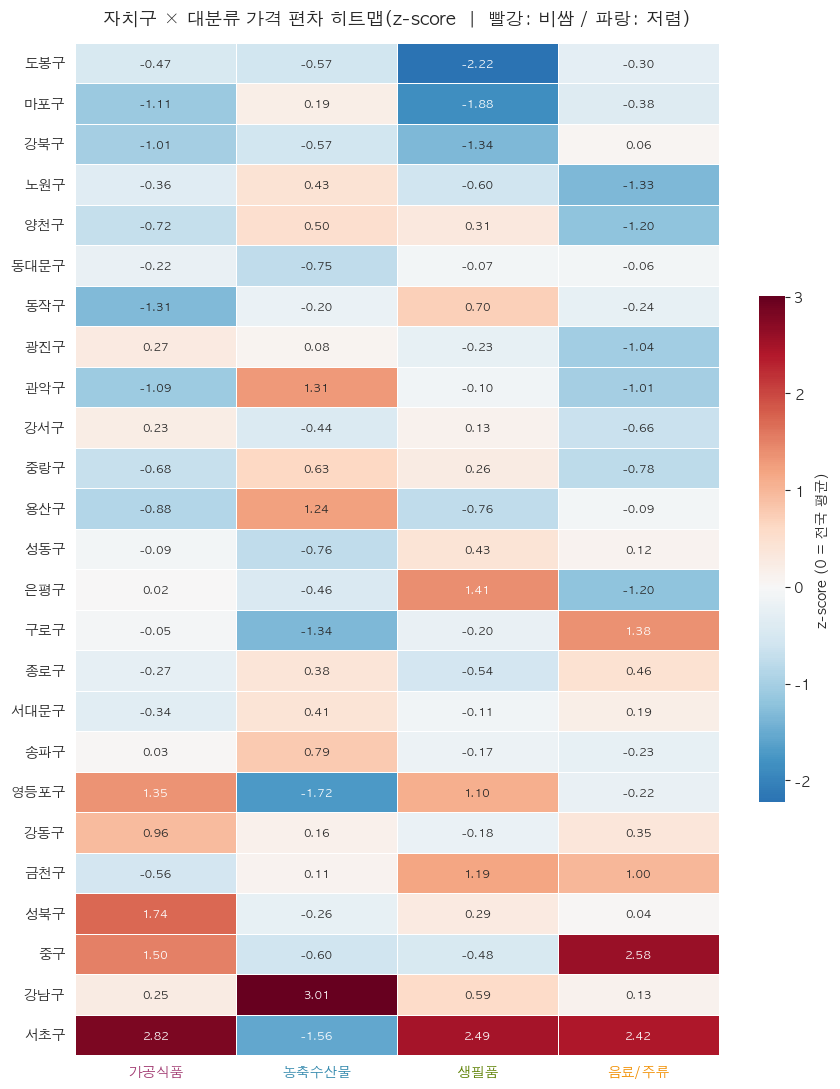

In [87]:
# VIZ-07의 district_cat, district_score 변수를 그대로 사용
pivot_district = (
    district_cat
    .pivot_table(index='자치구', columns='대분류', values='z_score')
)
# VIZ-07 정렬 순서 유지
pivot_district = pivot_district.reindex(district_score['자치구'].tolist())

fig, ax = plt.subplots(figsize=(9, 11))

sns.heatmap(
    pivot_district, ax=ax,
    cmap='RdBu_r', center=0,
    annot=True, fmt='.2f',
    linewidths=0.4, linecolor='white',
    cbar_kws={'label': 'z-score (0 = 전국 평균)', 'shrink': 0.5},
    annot_kws={'size': 8},
)

for tick_label in ax.get_xticklabels():
    cat = tick_label.get_text()
    tick_label.set_color(CATEGORY_COLORS.get(cat, '#333333'))
    tick_label.set_fontweight('bold')

ax.set_title('자치구 × 대분류 가격 편차 히트맵(z-score  |  빨강: 비쌈 / 파랑: 저렴)',
             fontsize=13, fontweight='bold', pad=14)
ax.set_xlabel('')
ax.set_ylabel('')

plt.tight_layout()
# plt.savefig(f'{OUTPUT_DIR}/viz_08_district_category_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
# print("✅ VIZ-08 저장 완료")

#### 자치구별 핵심 품목 가격 편차 (범프차트)

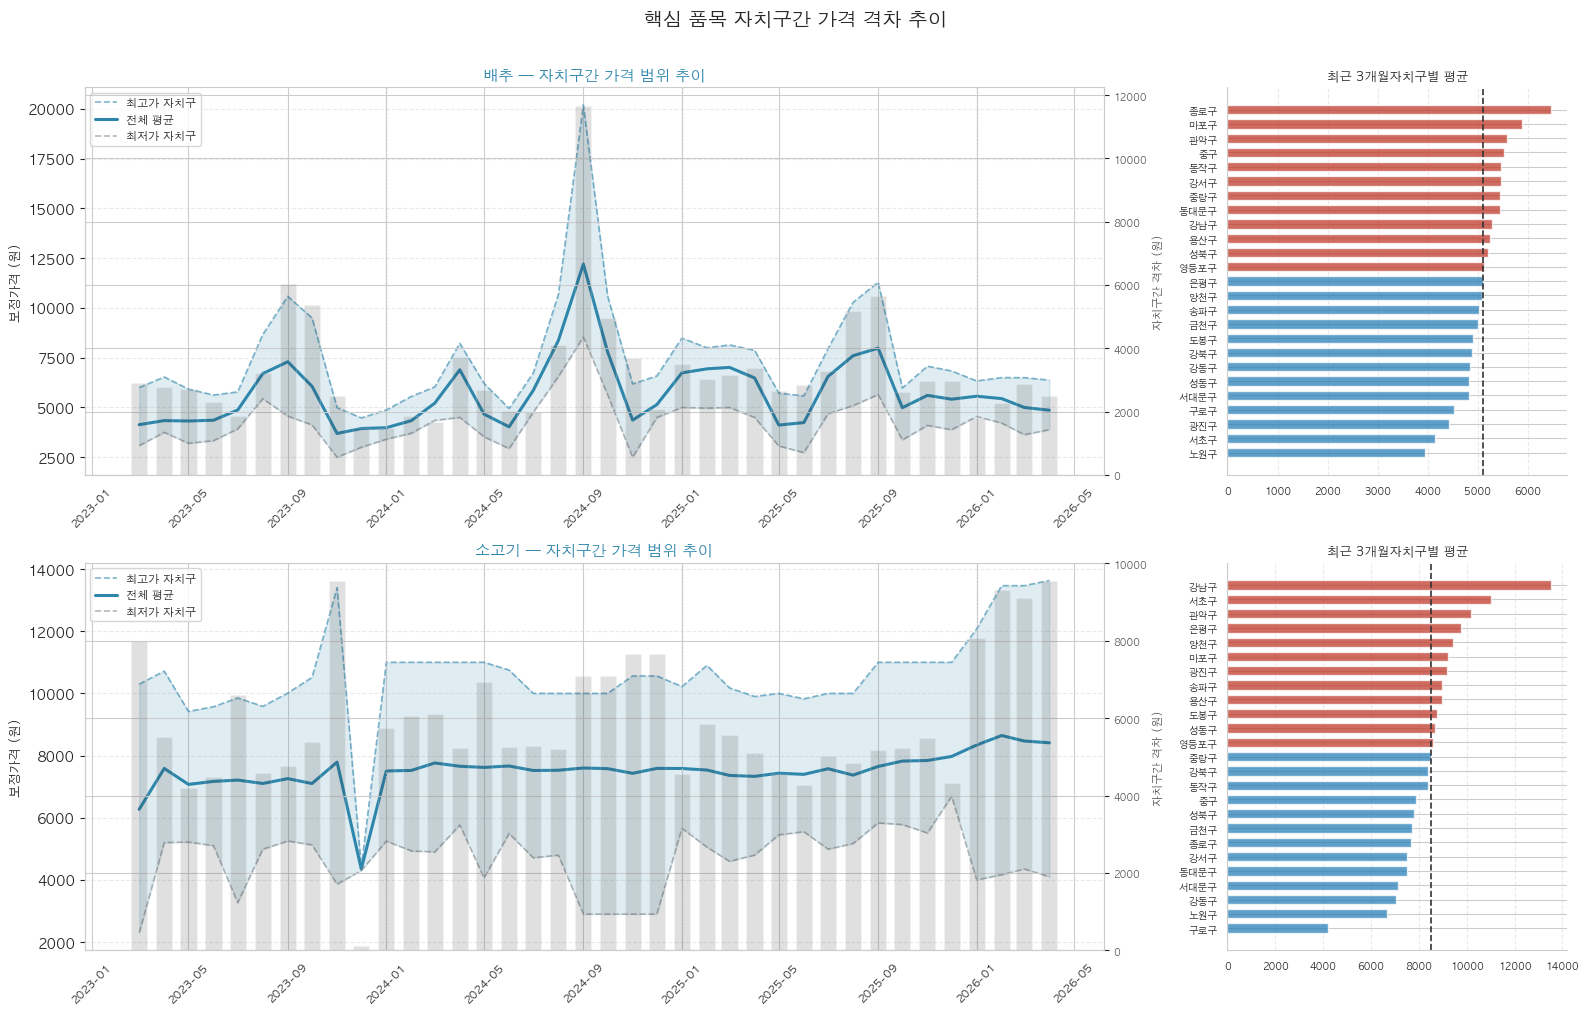

In [88]:
TARGET_ITEMS_09 = ['배추', '소고기']

fig, axes = plt.subplots(
    len(TARGET_ITEMS_09), 2,
    figsize=(16, 5 * len(TARGET_ITEMS_09)),
    gridspec_kw={'width_ratios': [3, 1]}
)

for row_idx, item in enumerate(TARGET_ITEMS_09):
    ax_line = axes[row_idx][0]
    ax_bar  = axes[row_idx][1]

    data = (
        df_clean[df_clean['대표품목명'] == item]
        .groupby(['연월_period', '자치구'])['보정가격']
        .mean()
        .reset_index()
        .sort_values('연월_period')
    )
    if data.empty:
        continue

    stats = (
        data.groupby('연월_period')['보정가격']
        .agg(최고='max', 평균='mean', 최저='min',
             격차=lambda x: x.max() - x.min())
        .reset_index()
    )
    x     = stats['연월_period'].dt.to_timestamp()
    cat   = df_clean[df_clean['대표품목명'] == item]['대분류'].iloc[0]
    color = CATEGORY_COLORS.get(cat, '#888888')

    # 최고/평균/최저 + 격차 영역
    ax_line.fill_between(x, stats['최고'], stats['최저'],
                         alpha=0.15, color=color)
    ax_line.plot(x, stats['최고'], '--', color=color, alpha=0.6,
                 linewidth=1.2, label='최고가 자치구')
    ax_line.plot(x, stats['평균'], '-',  color=color, linewidth=2.2,
                 label='전체 평균')
    ax_line.plot(x, stats['최저'], '--', color='#888888', alpha=0.6,
                 linewidth=1.2, label='최저가 자치구')

    ax2 = ax_line.twinx()
    ax2.bar(x, stats['격차'], width=20, alpha=0.15, color='#333333')
    ax2.set_ylabel('자치구간 격차 (원)', fontsize=8, color='#555555')
    ax2.tick_params(axis='y', labelsize=7, labelcolor='#555555')

    for year in [2024, 2025, 2026]:
        ax_line.axvline(pd.Timestamp(f'{year}-01-01'),
                        color='#cccccc', linestyle=':', linewidth=1)

    ax_line.set_title(f'{item} — 자치구간 가격 범위 추이',
                      fontsize=11, fontweight='bold', color=color)
    ax_line.set_ylabel('보정가격 (원)', fontsize=9)
    ax_line.legend(fontsize=8, loc='upper left')
    ax_line.tick_params(axis='x', rotation=45, labelsize=8)
    ax_line.grid(axis='y', linestyle='--', alpha=0.4)
    ax_line.spines[['top']].set_visible(False)

    # 최근 3개월 자치구별 평균 바 차트
    recent_3m   = data['연월_period'].max() - 2
    recent_data = (
        data[data['연월_period'] >= recent_3m]
        .groupby('자치구')['보정가격']
        .mean()
        .sort_values(ascending=True)
    )
    bar_colors = [
        '#c0392b' if v > recent_data.mean() else '#2980b9'
        for v in recent_data.values
    ]
    ax_bar.barh(recent_data.index, recent_data.values,
                color=bar_colors, alpha=0.75, height=0.65)
    ax_bar.axvline(recent_data.mean(), color='#333333',
                   linewidth=1.2, linestyle='--')
    ax_bar.set_title('최근 3개월자치구별 평균', fontsize=9, fontweight='bold')
    ax_bar.tick_params(axis='both', labelsize=7)
    ax_bar.grid(axis='x', linestyle='--', alpha=0.4)
    ax_bar.spines[['top', 'right']].set_visible(False)

plt.suptitle('핵심 품목 자치구간 가격 격차 추이',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
# plt.savefig(f'{OUTPUT_DIR}/viz_09_district_gap.png', dpi=150, bbox_inches='tight')
plt.show()
# print("✅ VIZ-09 저장 완료")

#### 지역별 심화

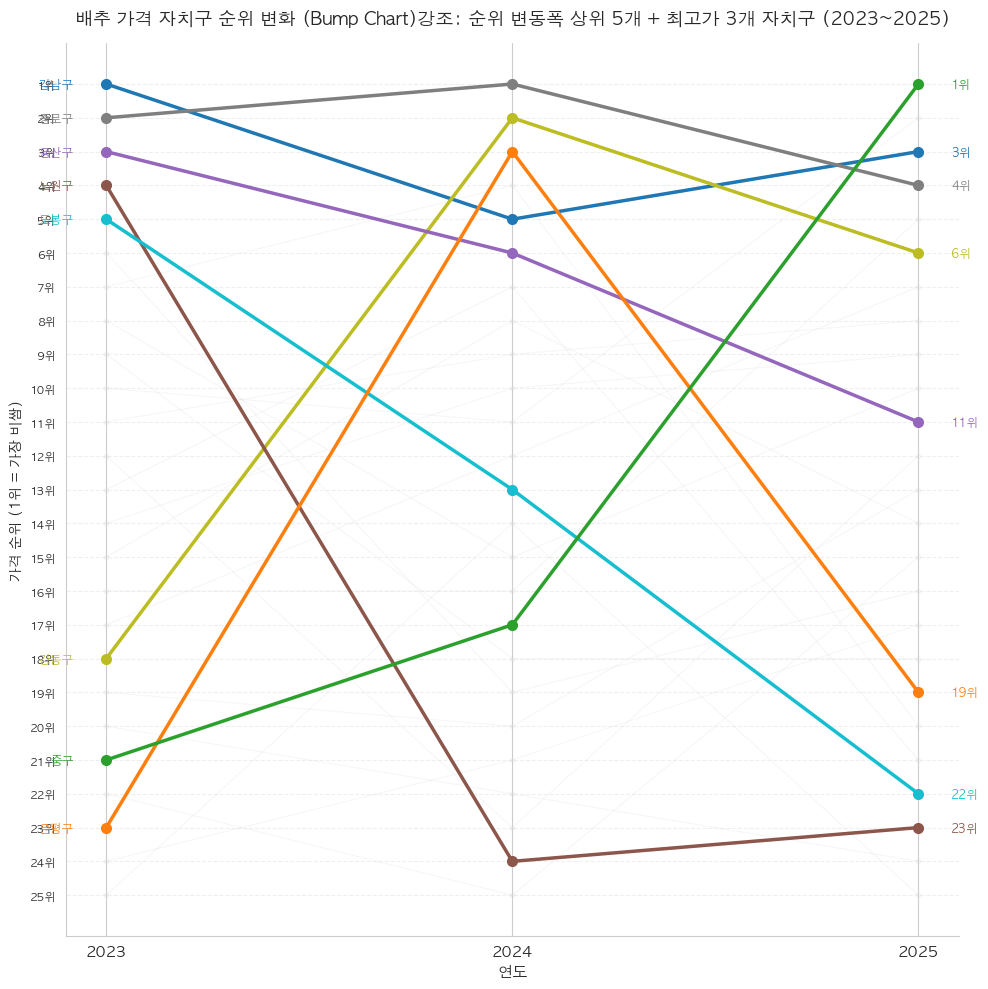

In [89]:
TARGET_ITEM_10 = '배추'   # 계절성이 뚜렷한 채소류 선택

# ── 1. 연도별 자치구 평균가격 및 순위 계산 ───────────────────────
# 2026년은 4개월치 데이터로 순위가 불안정 → 2023~2025만 사용
yearly_rank = (
    df_clean[
        (df_clean['대표품목명'] == TARGET_ITEM_10) &
        (df_clean['점검일자'].dt.year <= 2025)
    ]
    .assign(연도=lambda x: x['점검일자'].dt.year)
    .groupby(['연도', '자치구'])['보정가격']
    .mean()
    .reset_index()
)
yearly_rank['순위'] = (
    yearly_rank.groupby('연도')['보정가격']
    .rank(ascending=False, method='min')
    .astype(int)
)

years     = sorted(yearly_rank['연도'].unique())
districts = yearly_rank['자치구'].unique()

# ── 2. 강조 자치구 선정 (변동폭 상위 5 + 첫해 최고가 3) ─────────
rank_pivot = yearly_rank.pivot_table(
    index='자치구', columns='연도', values='순위')
rank_pivot['변동폭'] = rank_pivot.max(axis=1) - rank_pivot.min(axis=1)

top5_volatile  = rank_pivot.nlargest(5, '변동폭').index.tolist()
top3_expensive = rank_pivot[years[0]].nsmallest(3).index.tolist()
highlight      = list(set(top5_volatile + top3_expensive))

palette   = plt.cm.get_cmap('tab10', len(highlight))
color_map = {d: palette(i) for i, d in enumerate(highlight)}

# ── 3. 시각화 ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 10))

for district in districts:
    data         = yearly_rank[yearly_rank['자치구'] == district].sort_values('연도')
    is_highlight = district in highlight
    color        = color_map.get(district, '#dddddd')
    lw           = 2.5 if is_highlight else 0.8
    alpha        = 1.0 if is_highlight else 0.25
    zorder       = 5 if is_highlight else 1

    ax.plot(data['연도'], data['순위'],
            color=color, linewidth=lw, alpha=alpha, zorder=zorder,
            marker='o', markersize=7 if is_highlight else 3)

    if is_highlight:
        first = data.iloc[0]
        last  = data.iloc[-1]
        ax.text(first['연도'] - 0.08, first['순위'],
                district, ha='right', va='center',
                fontsize=8.5, color=color, fontweight='bold')
        ax.text(last['연도'] + 0.08, last['순위'],
                f"{int(last['순위'])}위",
                ha='left', va='center', fontsize=8.5, color=color)

ax.set_yticks(range(1, len(districts) + 1))
ax.set_yticklabels([f'{i}위' for i in range(1, len(districts) + 1)], fontsize=8)
ax.set_xticks(years)
ax.set_xticklabels([str(y) for y in years], fontsize=11)
ax.invert_yaxis()

ax.set_title(
    f'{TARGET_ITEM_10} 가격 자치구 순위 변화 (Bump Chart)'
    '강조: 순위 변동폭 상위 5개 + 최고가 3개 자치구 (2023~2025)',
    fontsize=13, fontweight='bold', pad=14)
ax.set_xlabel('연도', fontsize=11)
ax.set_ylabel('가격 순위 (1위 = 가장 비쌈)', fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
# plt.savefig(f'{OUTPUT_DIR}/viz_10_bump_chart.png', dpi=150, bbox_inches='tight')
plt.show()
# print("✅ VIZ-10 저장 완료")

### 종합 시각화

In [90]:
# ── 1. 드롭다운 대상: 데이터 건수 상위 20개 품목 ─────────────────
items_for_dropdown = (
    df_clean.groupby('대표품목명')['보정가격']
    .count().nlargest(20).index.tolist()
)

# ── 2. 품목별 데이터 사전 준비 ────────────────────────────────────
item_traces_line = {}
item_traces_bar  = {}

for item in items_for_dropdown:
    cat   = df_clean[df_clean['대표품목명'] == item]['대분류'].iloc[0]
    color = CATEGORY_COLORS.get(cat, '#888888')

    monthly = (
        df_clean[df_clean['대표품목명'] == item]
        .groupby('연월_period')['보정가격']
        .mean().reset_index().sort_values('연월_period')
    )
    monthly['x'] = monthly['연월_period'].dt.to_timestamp()
    item_traces_line[item] = (monthly, color)

    recent_3m   = df_clean['연월_period'].max() - 2
    district_avg = (
        df_clean[
            (df_clean['대표품목명'] == item) &
            (df_clean['연월_period'] >= recent_3m)
        ]
        .groupby('자치구')['보정가격']
        .mean().sort_values(ascending=True).reset_index()
    )
    item_traces_bar[item] = (district_avg, color)

# ── 3. 초기 품목 traces ───────────────────────────────────────────
init_item = items_for_dropdown[0]
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=['월별 평균가격 추이', '최근 3개월 자치구별 평균'],
    column_widths=[0.6, 0.4],
)

monthly_init, ci = item_traces_line[init_item]
fig.add_trace(
    go.Scatter(x=monthly_init['x'], y=monthly_init['보정가격'],
               mode='lines+markers', name='월 평균',
               line=dict(color=ci, width=2.5), marker=dict(size=5)),
    row=1, col=1
)

bar_init, ci2 = item_traces_bar[init_item]
fig.add_trace(
    go.Bar(x=bar_init['보정가격'], y=bar_init['자치구'],
           orientation='h', name='자치구 평균',
           marker_color=ci2, opacity=0.8),
    row=1, col=2
)

# ── 4. 드롭다운 버튼 ──────────────────────────────────────────────
buttons = []
for item in items_for_dropdown:
    m, lc  = item_traces_line[item]
    b, bc  = item_traces_bar[item]
    buttons.append(dict(
        label=item, method='update',
        args=[
            {'x': [m['x'], b['보정가격']],
             'y': [m['보정가격'], b['자치구']],
             'marker.color': [lc, bc],
             'line.color':   [lc, bc]},
            {'title': f'📊  {item}  —  인터랙티브 가격 탐색 대시보드'}
        ]
    ))

fig.update_layout(
    title=f'📊  {init_item}  —  인터랙티브 가격 탐색 대시보드',
    title_font_size=16,
    updatemenus=[dict(
        buttons=buttons, direction='down', showactive=True,
        x=0.0, xanchor='left', y=1.15, yanchor='top',
        bgcolor='#f8f8f8', bordercolor='#cccccc',
    )],
    height=520, showlegend=False, plot_bgcolor='#fafafa',
)
fig.update_xaxes(showgrid=True, gridcolor='#eeeeee')
fig.update_yaxes(showgrid=True, gridcolor='#eeeeee')

# fig.write_html(f'{OUTPUT_DIR}/viz_11_interactive_dashboard.html')
fig.show()
# print("✅ VIZ-11 저장 완료 (HTML)")

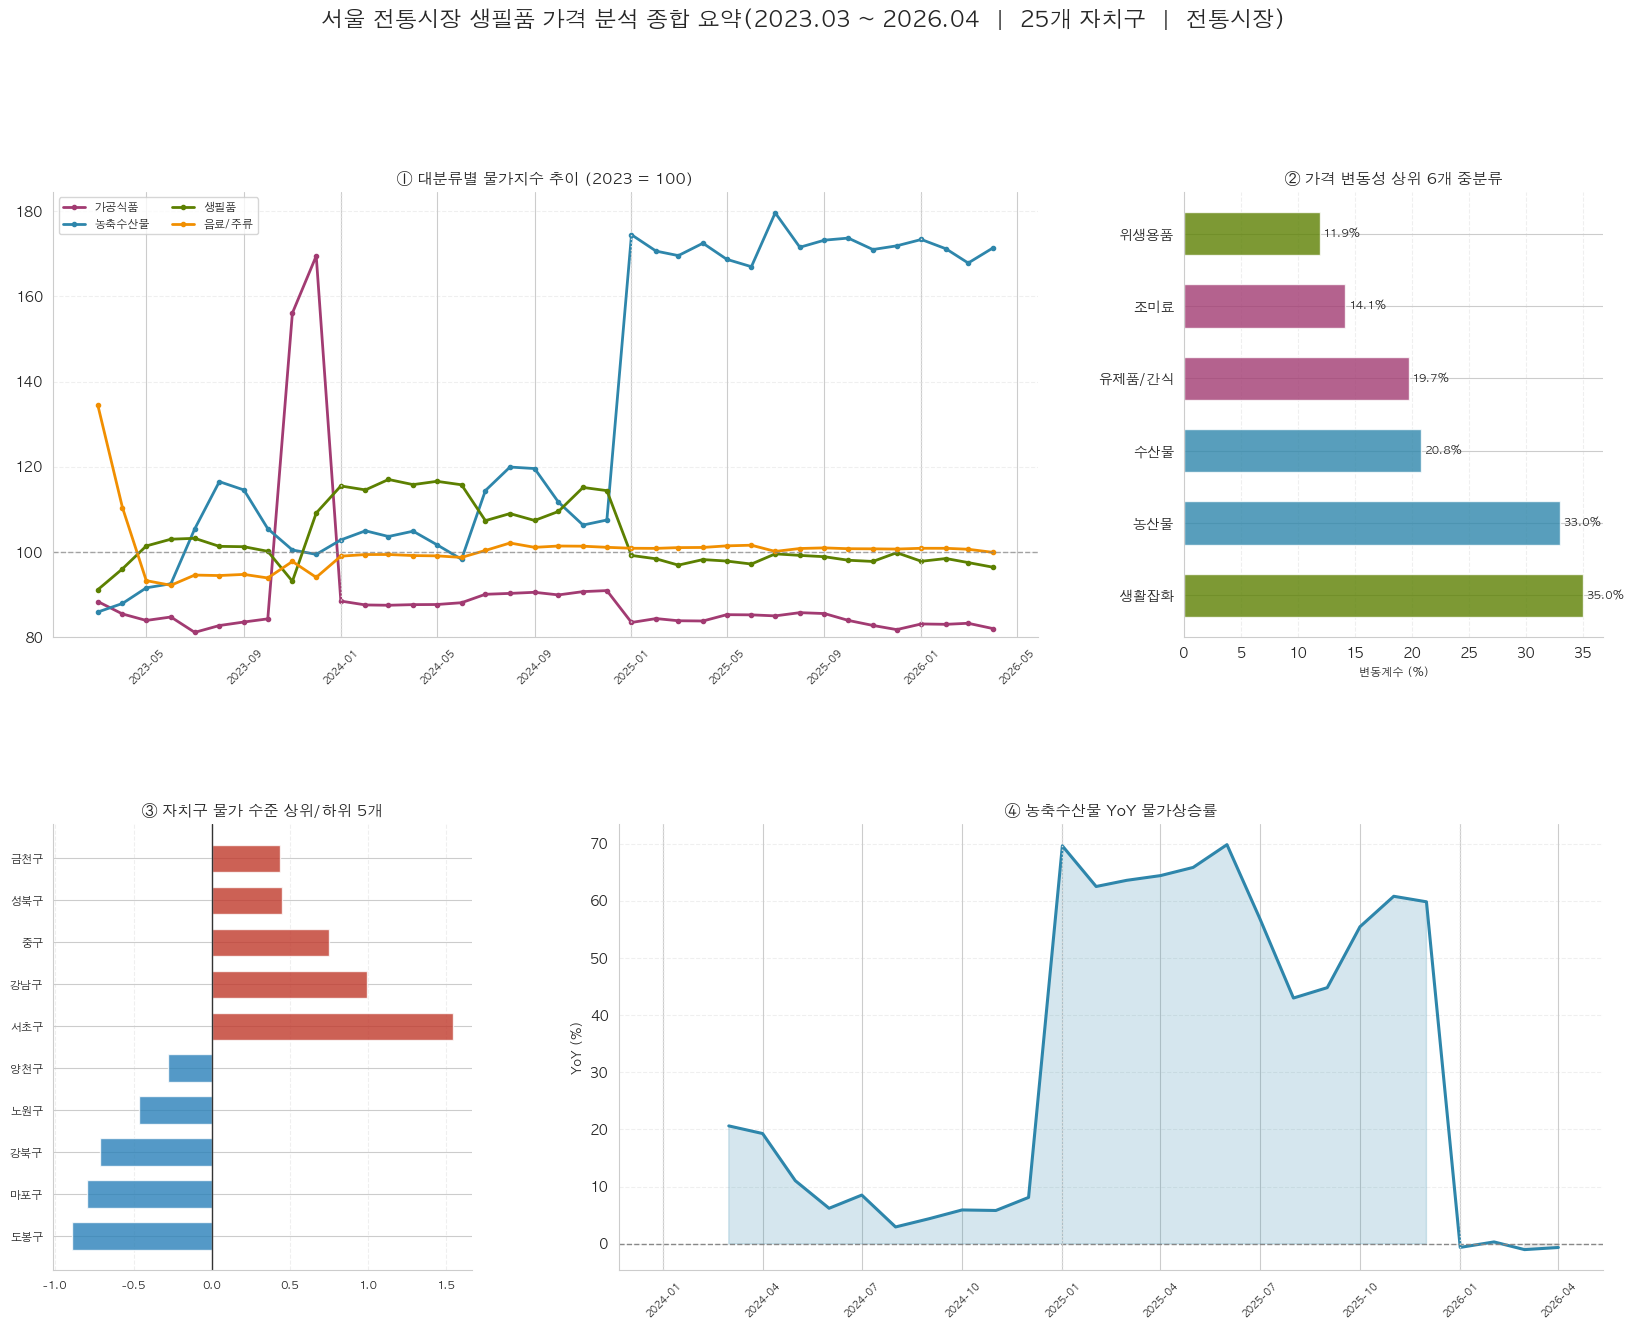

In [91]:
fig = plt.figure(figsize=(20, 14))
gs  = fig.add_gridspec(2, 3, hspace=0.42, wspace=0.35)

ax1 = fig.add_subplot(gs[0, :2])   # 물가지수 추이 (넓게)
ax2 = fig.add_subplot(gs[0, 2])    # 변동계수 상위 6개
ax3 = fig.add_subplot(gs[1, 0])    # 자치구 물가 점수 (상위/하위 5)
ax4 = fig.add_subplot(gs[1, 1:])   # 농축수산물 YoY

# ── 패널 1: 물가지수 추이 ─────────────────────────────────────────
for cat, group in monthly_cat.groupby('대분류'):
    x = group['연월'].dt.to_timestamp()
    ax1.plot(x, group['물가지수'], label=cat,
             color=CATEGORY_COLORS.get(cat), linewidth=2,
             marker='o', markersize=3)
ax1.axhline(100, color='gray', linestyle='--', linewidth=1, alpha=0.7)
for year in [2024, 2025, 2026]:
    ax1.axvline(pd.Timestamp(f'{year}-01-01'),
                color='#dddddd', linestyle=':', linewidth=1)
ax1.set_title('① 대분류별 물가지수 추이 (2023 = 100)',
              fontweight='bold', fontsize=11)
ax1.legend(fontsize=8, loc='upper left', ncol=2)
ax1.set_ylim(bottom=80)
ax1.tick_params(axis='x', rotation=45, labelsize=7)
ax1.grid(axis='y', linestyle='--', alpha=0.3)
ax1.spines[['top', 'right']].set_visible(False)

# ── 패널 2: 변동계수 상위 6개 ────────────────────────────────────
top6_cv = cv_df.nlargest(6, '변동계수')
ax2.barh(top6_cv['중분류'], top6_cv['변동계수'],
         color=[CATEGORY_COLORS.get(c, '#888') for c in top6_cv['대분류']],
         alpha=0.8, height=0.6)
for bar, val in zip(ax2.patches, top6_cv['변동계수']):
    ax2.text(bar.get_width() + 0.3,
             bar.get_y() + bar.get_height() / 2,
             f'{val:.1f}%', va='center', fontsize=8)
ax2.set_title('② 가격 변동성 상위 6개 중분류', fontweight='bold', fontsize=11)
ax2.set_xlabel('변동계수 (%)', fontsize=8)
ax2.grid(axis='x', linestyle='--', alpha=0.3)
ax2.spines[['top', 'right']].set_visible(False)

# ── 패널 3: 자치구 물가 점수 상위/하위 5개 ───────────────────────
top5    = district_score.nlargest(5, '물가점수')
bottom5 = district_score.nsmallest(5, '물가점수')
combined = pd.concat([bottom5, top5]).reset_index(drop=True)
colors3  = ['#2980b9'] * 5 + ['#c0392b'] * 5

ax3.barh(combined['자치구'], combined['물가점수'],
         color=colors3, alpha=0.8, height=0.65)
ax3.axvline(0, color='#333', linewidth=1)
ax3.set_title('③ 자치구 물가 수준 상위/하위 5개', fontweight='bold', fontsize=11)
ax3.tick_params(labelsize=8)
ax3.grid(axis='x', linestyle='--', alpha=0.3)
ax3.spines[['top', 'right']].set_visible(False)

# ── 패널 4: 농축수산물 YoY ────────────────────────────────────────
target_cat = '농축수산물'
if target_cat in yoy_df.columns:
    series = yoy_df[target_cat].dropna()
    x4     = series.index.to_timestamp()
    y4     = series.values
    color4 = CATEGORY_COLORS[target_cat]

    ax4.fill_between(x4, y4, 0, where=(y4 >= 0), alpha=0.2, color=color4)
    ax4.fill_between(x4, y4, 0, where=(y4 < 0),  alpha=0.2, color='#aaaaaa')
    ax4.plot(x4, y4, color=color4, linewidth=2.2)
    ax4.axhline(0, color='#888', linewidth=1, linestyle='--')
    for year in [2024, 2025, 2026]:
        ax4.axvline(pd.Timestamp(f'{year}-01-01'),
                    color='#dddddd', linestyle=':', linewidth=1)
    ax4.set_title(f'④ {target_cat} YoY 물가상승률',
                  fontweight='bold', fontsize=11)
    ax4.set_ylabel('YoY (%)', fontsize=9)
    ax4.tick_params(axis='x', rotation=45, labelsize=7)
    ax4.grid(axis='y', linestyle='--', alpha=0.3)
    ax4.spines[['top', 'right']].set_visible(False)

fig.suptitle(
    '서울 전통시장 생필품 가격 분석 종합 요약'
    '(2023.03 ~ 2026.04  |  25개 자치구  |  전통시장)',
    fontsize=16, fontweight='bold', y=1.01)

# plt.savefig(f'{OUTPUT_DIR}/viz_12_summary_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
# print("✅ VIZ-12 저장 완료")

# 대시보드 설계

## 인터랙티브 대시보드 설계

---

## 도구 선택 기준

먼저 두 도구의 특성을 비교합니다.

| 항목 | Streamlit | Tableau |
|------|-----------|---------|
| 학습 난이도 | 낮음 (Python 그대로) | 중간 (GUI 기반) |
| 커스터마이징 | 자유도 높음 | 제한적 |
| 배포 | Streamlit Cloud (무료) | Public 무료 / 유료 |
| 포트폴리오 공유 | URL 공유 | URL 공유 |
| 데이터 연동 | CSV / DB 직접 로드 | CSV / DB 연결 |
| 인터랙션 구현 | 코드로 직접 구현 | 드래그앤드롭 |

**추천: Streamlit**

이유는 세 가지입니다. 전처리 코드가 이미 Python으로 작성되어 있어 `df_clean`을 그대로 연동할 수 있고, Streamlit Cloud로 무료 배포 후 GitHub 링크를 포트폴리오에 바로 연결할 수 있으며, 이미 작성한 Plotly / Matplotlib 코드를 거의 그대로 재사용할 수 있습니다.

---

## 대시보드 구조 설계

**전체 구성: 4개 페이지 (멀티페이지 앱)**

```
📁 app/
├── 🏠 Home.py              ← 메인 진입점 + 프로젝트 개요
└── 📁 pages/
    ├── 1_전체현황.py
    ├── 2_시계열분석.py
    ├── 3_지역별분석.py
    └── 4_품목탐색.py       ← VIZ-11 인터랙티브 확장판
```

---

## 페이지별 상세 설계

### 🏠 Home — 프로젝트 개요 + KPI 카드

```
┌─────────────────────────────────────────────────────┐
│  서울 전통시장 생필품 가격 분석 대시보드             │
│  2023.03 ~ 2026.04  |  25개 자치구  |  전통시장     │
├──────────┬──────────┬──────────┬────────────────────┤
│ 분석기간  │ 자치구 수 │ 분석품목  │  총 데이터 건수    │
│ 37개월   │   25개   │   N개    │    N만 건          │
├──────────┴──────────┴──────────┴────────────────────┤
│  [프로젝트 배경 및 분석 목적 텍스트]                 │
│  [분석 흐름 다이어그램]                              │
└─────────────────────────────────────────────────────┘
```

**구현 컴포넌트**
- `st.metric()` — KPI 카드 4개
- `st.columns()` — 4분할 레이아웃
- `st.markdown()` — 프로젝트 설명

---

### 📄 Page 1 — 전체 현황

```
┌─ 사이드바 필터 ──┐  ┌─ 메인 영역 ──────────────────────┐
│ 대분류 선택      │  │  [물가지수 추이 — VIZ-01]         │
│ ☑ 농축수산물    │  │                                   │
│ ☑ 가공식품      │  ├───────────────────────────────────┤
│ ☑ 음료/주류     │  │  [변동계수 바 차트 — VIZ-02]       │
│ ☑ 생필품        │  │                                   │
│                  │  ├───────────────────────────────────┤
│ 기간 선택        │  │  💡 자동 인사이트 텍스트           │
│ 2023-03 ~        │  │  "가장 많이 오른 대분류: 농축수산물│
│ 2026-04          │  │   가장 변동성 높은 품목: 농산물"   │
└──────────────────┘  └───────────────────────────────────┘
```

**구현 컴포넌트**
- `st.sidebar.multiselect()` — 대분류 필터
- `st.sidebar.date_input()` — 기간 슬라이더
- `st.plotly_chart()` — VIZ-01, 02 Plotly 버전
- `st.info()` — 자동 인사이트 텍스트

---

### 📄 Page 2 — 시계열 분석

```
┌─ 사이드바 필터 ──┐  ┌─ 탭 구조 ────────────────────────┐
│ 품목 선택        │  │ [계절패턴] [YoY] [품목추이] [분기] │
│ (멀티셀렉트)     │  ├───────────────────────────────────┤
│                  │  │  탭 1: 계절별 히트맵 — VIZ-03     │
│ 분석 단위        │  │  탭 2: YoY 차트 — VIZ-04          │
│ ○ 대분류         │  │  탭 3: 품목 시계열 — VIZ-05       │
│ ○ 중분류         │  │  탭 4: 분기 박스플롯 — VIZ-06     │
│ ● 품목           │  │                                   │
└──────────────────┘  └───────────────────────────────────┘
```

**구현 컴포넌트**
- `st.tabs()` — 4개 탭 전환
- `st.selectbox()` — 분석 단위 선택
- `st.multiselect()` — 품목 다중 선택
- `st.plotly_chart(use_container_width=True)` — 반응형 차트

---

### 📄 Page 3 — 지역별 분석

```
┌─ 사이드바 필터 ──┐  ┌─ 상단: 지도 + 바 차트 ───────────┐
│ 품목/대분류 선택  │  │  [자치구 choropleth 지도]         │
│                  │  │  (또는 VIZ-07 바 차트)            │
│ 비교 자치구 선택  │  ├───────────────────────────────────┤
│ (최대 5개)       │  │  [자치구 × 대분류 히트맵 — VIZ-08] │
│                  │  ├───────────────────────────────────┤
│ 연도 선택        │  │  [선택 자치구 간 가격 비교]         │
│ ○ 전체           │  │  (Plotly line — 복수 자치구 겹치기) │
│ ○ 2023           │  ├───────────────────────────────────┤
│ ○ 2024           │  │  [Bump Chart — VIZ-10]            │
│ ○ 2025           │  │                                   │
└──────────────────┘  └───────────────────────────────────┘
```

**구현 컴포넌트**
- `st.multiselect()` — 자치구 비교 선택 (최대 5개 제한)
- `st.radio()` — 연도 선택
- `px.choropleth_mapbox()` — 지도 (GeoJSON 있을 경우)
- `st.plotly_chart()` — 히트맵, 범프차트

---

### 📄 Page 4 — 품목 탐색 (VIZ-11 확장)

```
┌─────────────────────────────────────────────────────┐
│  품목 선택: [드롭다운 or 검색창]                     │
├──────────────────────┬──────────────────────────────┤
│ 월별 가격 추이        │  자치구별 최근 평균가격        │
│ (이동평균 토글 포함)  │  (정렬 가능 바 차트)           │
├──────────────────────┴──────────────────────────────┤
│ 계절별 평균가격 (바 차트)  │  연도별 가격 요약 테이블  │
├───────────────────────────┴──────────────────────────┤
│  📋 원본 데이터 테이블 (필터링된 데이터 미리보기)     │
│  [CSV 다운로드 버튼]                                 │
└─────────────────────────────────────────────────────┘
```

**구현 컴포넌트**
- `st.selectbox()` — 품목 선택 (검색 가능)
- `st.toggle()` — 이동평균 표시 여부
- `st.columns(2)` — 2분할 차트 배치
- `st.dataframe()` — 원본 데이터 테이블
- `st.download_button()` — CSV 다운로드

---

## 공통 사이드바 구성

```
┌─ 사이드바 ───────────────┐
│ 🏪 서울 전통시장 가격분석 │
│                          │
│ [페이지 네비게이션]       │
│                          │
│ ─── 공통 필터 ─────────  │
│ 📅 분석 기간              │
│   시작: 2023-03           │
│   종료: 2026-04           │
│                          │
│ 🏘️ 시장유형               │
│   ● 전통시장 (고정)       │
│                          │
│ ─── 데이터 정보 ───────  │
│ 마지막 업데이트: N        │
│ 총 데이터: N만 건         │
└──────────────────────────┘
```

---

## 파일 구조 및 구현 순서

```
📁 seoul_price_dashboard/
├── Home.py
├── pages/
│   ├── 1_전체현황.py
│   ├── 2_시계열분석.py
│   ├── 3_지역별분석.py
│   └── 4_품목탐색.py
├── utils/
│   ├── data_loader.py    ← df_clean 로드 + 캐싱
│   └── chart_utils.py    ← 공통 차트 함수
├── data/
│   └── df_clean.csv      ← 전처리 완료 데이터
└── requirements.txt
```

**구현 순서**

```
1단계: data_loader.py 작성 (df_clean 로드 + st.cache_data)
2단계: chart_utils.py 작성 (기존 시각화 함수 Plotly 버전으로 이식)
3단계: Home.py (KPI 카드)
4단계: Page 1 → 2 → 3 → 4 순서로 구현
5단계: 배포 (Streamlit Cloud + GitHub 연동)
```

---

## 배포 방법 (Streamlit Cloud)

```
1. GitHub 레포지토리 생성 후 코드 업로드
2. share.streamlit.io 접속 → GitHub 연동
3. Main file: Home.py 지정
4. 배포 완료 → URL 공유
   예시: https://seoul-price.streamlit.app
```

---

어느 페이지부터 코드 작성할까요?